HybridForecasting ARIMA+LSTM (SAITS Imputed & Optimized with PSO) - COVID-19

In [1]:
import os
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, SimpleImputer
from sklearn.linear_model import BayesianRidge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from scipy.stats import entropy
from pypots.imputation import SAITS

/Users/acnmacm4/ACNM4_Workstation/1.MSDS_BatStateU/520MSDS_Thesis1/Thesis_ARIMA-BiLSTMATT/Thesis_CompletePipeline_V1/Thesis_HybridModel_Final/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



████████╗██╗███╗   ███╗███████╗    ███████╗███████╗██████╗ ██╗███████╗███████╗    █████╗ ██╗
╚══██╔══╝██║████╗ ████║██╔════╝    ██╔════╝██╔════╝██╔══██╗██║██╔════╝██╔════╝   ██╔══██╗██║
   ██║   ██║██╔████╔██║█████╗█████╗███████╗█████╗  ██████╔╝██║█████╗  ███████╗   ███████║██║
   ██║   ██║██║╚██╔╝██║██╔══╝╚════╝╚════██║██╔══╝  ██╔══██╗██║██╔══╝  ╚════██║   ██╔══██║██║
   ██║   ██║██║ ╚═╝ ██║███████╗    ███████║███████╗██║  ██║██║███████╗███████║██╗██║  ██║██║
   ╚═╝   ╚═╝╚═╝     ╚═╝╚══════╝    ╚══════╝╚══════╝╚═╝  ╚═╝╚═╝╚══════╝╚══════╝╚═╝╚═╝  ╚═╝╚═╝
ai4ts v0.0.3 - building AI for unified time-series analysis, https://time-series.ai 



In [2]:
#CONFIGURATION

DATASET_CONFIGS = [
    {
        "name": "Influenza_Study",
        "file": "diseases_multi_mg_final.csv",
        "date_col": "ISO_WEEKSTARTDATE",
        "country_col": "COUNTRY_AREA_TERRITORY",
        "targets": ["INF_ALL", "RSV"],
        "covariates": ["SPEC_PROCESSED_NB", "MEAN_TEMPERATURE", "Abs_Humidity", "RH_pct", "POPULATION_DENSITY", "POPULATION_GROWTH"],
        "output_file": "imputation_v5_influenza_merged.csv",
        "test_countries": ["United States of America", "Brazil", "South Africa", "India", "Germany"],
        # --- NEW: weekly de-duplication settings for the ORIGIN_SOURCE column ---
        "dup_source_col": "ORIGIN_SOURCE",          # column that splits one week into many rows
        "sum_cols": ["INF_ALL", "RSV", "SPEC_PROCESSED_NB"],  # counts -> add together across sources
        "mean_cols": ["MEAN_TEMPERATURE", "Abs_Humidity", "RH_pct", "POPULATION_DENSITY", "POPULATION_GROWTH"]  # context -> take one value
    },
    {
        "name": "COVID19_Study",
        "file": "covid19_multi_mg_final.csv",
        "date_col": "Date",
        "country_col": "Country/Region",
        "targets": ["new_cases"],
        "covariates": ["stringency_index"],
        "output_file": "imputation_v5_C19_merged.csv",
        "test_countries": ["US", "Brazil", "South Africa", "India", "Germany"],
        # COVID has no ORIGIN_SOURCE duplication -> leave as None
        "dup_source_col": None,
        "sum_cols": [],
        "mean_cols": []
    }
]

# Global Hyperparameters
MISSING_RATES = [0.1, 0.3, 0.5]
PATTERNS = ["Point", "Sequence", "Block"]
METHODS_SIMPLE = ['mean', 'median', 'most_frequent']
METHODS_PANDAS = ['LOCF', 'Linear', 'Rolling']
EPOCHS = 60
ENSEMBLE_RUNS = 2
MIN_DATA_POINTS = 300
DEVICE = "mps" if torch.backends.mps.is_available() else "cpu"

# ===================== EXPERIMENT TOGGLES =====================
# COUNTRY_SELECTION_MODE controls how test countries are chosen:
#   "random" -> picks countries at random (tests GENERALIZABILITY)
#   "fixed"  -> uses a fixed, hand-picked list  (tests REPRODUCIBILITY)
COUNTRY_SELECTION_MODE = "fixed"   # change to "random" or "fixed"

# How many countries to use per dataset when in "random" mode
N_RANDOM_COUNTRIES = 3

# Seed used for the random pick. Same seed = same "random" countries every run.
COUNTRY_RANDOM_SEED = 42

# The fixed country list used when COUNTRY_SELECTION_MODE == "fixed".
# These are locked in so results can be reproduced exactly by anyone.
FIXED_COUNTRY_SETS = {
    "Influenza_Study": ['Brazil','Germany','India','South Africa','United States of America'],
    "COVID19_Study":   ['Bhutan','Czechia','Montenegro','Sierra Leone','Spain']
}

# AGGREGATION_METHOD controls how duplicate weekly rows (one per ORIGIN_SOURCE)
# are merged into a single row:
#   "sum"   -> add the counts (use when sources count DIFFERENT patients)
#   "mean"  -> average everything (use when sources estimate the SAME number)
#   "first" -> keep the first source only, drop the rest
AGGREGATION_METHOD = "mean"
# ==============================================================

print(f"✅ Starting End-to-End Pipeline on: {DEVICE}")
print(f"   Country selection mode : {COUNTRY_SELECTION_MODE}")
print(f"   Weekly aggregation     : {AGGREGATION_METHOD}")


✅ Starting End-to-End Pipeline on: mps
   Country selection mode : fixed
   Weekly aggregation     : mean


In [13]:
"""
#checking row counts for the fixed country sets, to make sure the files are correct and the country names match
covid = pd.read_csv('covid19_multi_mg_final.csv')
flu   = pd.read_csv('diseases_multi_mg_final.csv')

covid_want = ['Bhutan','Czechia','Montenegro','Sierra Leone','Spain']
flu_want   = ['Brazil','Germany','India','South Africa','United States of America']

print("COVID row counts:")
for c in covid_want:
    print(f"  {c}: {(covid['Country/Region']==c).sum()}")
print("FLU row counts (after weekly dedup ~ /3):")
for c in flu_want:
    print(f"  {c}: {(flu['COUNTRY_AREA_TERRITORY']==c).sum()}")
    
"

_IncompleteInputError: incomplete input (4241721925.py, line 1)

In [3]:
#PREPROCESSING HELPERS

def diagnose_weekly_duplicates(df, cfg):
    """
    Checks whether one country+week has several rows because of the
    ORIGIN_SOURCE column. Prints a short report so you can SEE the problem
    before deciding how to fix it. Does NOT change the data.
    """
    src_col = cfg.get("dup_source_col")
    if not src_col or src_col not in df.columns:
        print(f"   [diagnose] No '{src_col}' column in {cfg['name']} -> nothing to de-duplicate.")
        return

    key = [cfg['country_col'], cfg['date_col']]
    group_sizes = df.groupby(key).size()
    n_dup_weeks = (group_sizes > 1).sum()
    total_weeks = len(group_sizes)

    print(f"   [diagnose] ORIGIN_SOURCE categories : {sorted(df[src_col].dropna().unique().tolist())}")
    print(f"   [diagnose] Country+week groups       : {total_weeks}")
    print(f"   [diagnose] Groups with >1 row (dups) : {n_dup_weeks} "
          f"({100*n_dup_weeks/max(total_weeks,1):.1f}%)")
    print(f"   [diagnose] Max rows in one week      : {group_sizes.max()}")

    # Check if covariates are identical across the duplicate sources
    mean_cols = [c for c in cfg.get("mean_cols", []) if c in df.columns]
    if mean_cols and n_dup_weeks > 0:
        dup_keys = group_sizes[group_sizes > 1].index
        sample_key = dup_keys[0]
        sample = df.set_index(key).loc[[sample_key], mean_cols]
        identical = sample.nunique().le(1).all()
        print(f"   [diagnose] Covariates identical across sources? -> {bool(identical)}")
        if not identical:
            print(f"   [diagnose]  (covariates differ -> they will be averaged)")


def deduplicate_weekly(df, cfg, method="sum"):
    """
    Turns several rows for the same country+week (one per ORIGIN_SOURCE)
    into ONE clean row.

    method = "sum"   -> count columns are added together (different patients)
    method = "mean"  -> every numeric column is averaged (same-number estimates)
    method = "first" -> keep the first source only, drop the others

    Example (one country, one week, 3 sources):
        ORIGIN_SOURCE   INF_ALL   MEAN_TEMPERATURE
        SENTINEL        40        12.0
        NONSENTINEL     25        12.0
        NOTDEFINED       5        12.0
      method="sum"  -> INF_ALL = 70 , MEAN_TEMPERATURE = 12.0
      method="mean" -> INF_ALL ~= 23.3 , MEAN_TEMPERATURE = 12.0
      method="first"-> INF_ALL = 40 , MEAN_TEMPERATURE = 12.0
    """
    src_col = cfg.get("dup_source_col")
    if not src_col or src_col not in df.columns:
        return df  # nothing to do (e.g. COVID dataset)

    key = [cfg['country_col'], cfg['date_col']]
    before = len(df)

    if method == "first":
        out = df.sort_values(key).groupby(key, as_index=False).first()

    elif method == "mean":
        # average every numeric column; keep first value of text columns
        num_cols = df.select_dtypes('number').columns.tolist()
        txt_cols = [c for c in df.columns if c not in num_cols and c not in key]
        agg = {c: 'mean' for c in num_cols}
        agg.update({c: 'first' for c in txt_cols})
        out = df.groupby(key, as_index=False).agg(agg)

    else:  # "sum"  -> add counts, average context columns, keep first for text
        sum_cols  = [c for c in cfg.get("sum_cols", [])  if c in df.columns]
        mean_cols = [c for c in cfg.get("mean_cols", []) if c in df.columns]
        used = set(sum_cols + mean_cols + key)
        other_cols = [c for c in df.columns if c not in used]

        agg = {c: 'sum'   for c in sum_cols}
        agg.update({c: 'mean'  for c in mean_cols})
        agg.update({c: 'first' for c in other_cols})  # incl. ORIGIN_SOURCE label
        out = df.groupby(key, as_index=False).agg(agg)

    after = len(out)
    print(f"   [dedup] {cfg['name']}: {before} rows -> {after} rows "
          f"(removed {before-after} duplicate source rows, method='{method}')")
    return out


def select_countries(df_raw, cfg):
    """
    Picks which countries to test, based on the COUNTRY_SELECTION_MODE toggle.

      "fixed"  -> use FIXED_COUNTRY_SETS  (exact same countries every run -> REPRODUCIBLE)
      "random" -> pick N_RANDOM_COUNTRIES at random from countries that have
                  enough data (different countries possible -> tests GENERALIZABILITY)

    A country is only allowed if it has at least MIN_DATA_POINTS rows.
    """
    counts = df_raw[cfg['country_col']].value_counts()
    valid_countries = counts[counts >= MIN_DATA_POINTS].index.tolist()

    if COUNTRY_SELECTION_MODE == "fixed":
        wanted = FIXED_COUNTRY_SETS.get(cfg['name'], cfg.get('test_countries', []))
        chosen = [c for c in wanted if c in valid_countries]
        dropped = [c for c in wanted if c not in valid_countries]
        if dropped:
            print(f"   ⚠️  Fixed countries dropped (not enough data): {dropped}")
        print(f"   📌 FIXED mode -> {chosen}")
        return chosen

    elif COUNTRY_SELECTION_MODE == "random":
        if len(valid_countries) >= N_RANDOM_COUNTRIES:
            np.random.seed(COUNTRY_RANDOM_SEED)
            chosen = np.random.choice(valid_countries,
                                      size=N_RANDOM_COUNTRIES,
                                      replace=False).tolist()
            print(f"   🎲 RANDOM mode (seed={COUNTRY_RANDOM_SEED}) -> {chosen}")
            return chosen
        else:
            fallback = cfg.get('test_countries', [])
            print(f"   ⚠️  Not enough valid countries. Falling back to: {fallback}")
            return fallback

    else:
        raise ValueError(f"COUNTRY_SELECTION_MODE must be 'random' or 'fixed', "
                         f"got '{COUNTRY_SELECTION_MODE}'")


In [4]:
#MASK GENERATION
class MaskGenerator:
    @staticmethod
    def get_mask(pattern, n_steps, rate, seed=42):
        np.random.seed(seed)
        if pattern == "Point":
            return np.random.rand(n_steps) > rate
        elif pattern == "Sequence":
            mask = np.ones(n_steps, dtype=bool)
            n_missing = int(n_steps * rate)
            seq_len = 4
            num_seqs = max(1, n_missing // seq_len)
            for _ in range(num_seqs):
                start = np.random.randint(0, max(1, n_steps - seq_len))
                mask[start : start + seq_len] = False
            return mask
        elif pattern == "Block":
            block_len = int(n_steps * rate)
            start = np.random.randint(0, max(1, n_steps - block_len))
            mask = np.ones(n_steps, dtype=bool)
            mask[start : start + block_len] = False
            return mask
        return np.ones(n_steps, dtype=bool)

#METRICS EVALUATION

class MetricsVault:
    @staticmethod
    def calculate_all(y_true, y_pred, y_train_historical=None):
        mae = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
            
        try:
            bins = np.histogram_bin_edges(np.concatenate([y_true, y_pred]), bins='auto')
            hist_true, _ = np.histogram(y_true, bins=bins, density=True)
            hist_pred, _ = np.histogram(y_pred, bins=bins, density=True)
            
            epsilon = 1e-10
            p = (hist_true + epsilon) / np.sum(hist_true + epsilon)
            q = (hist_pred + epsilon) / np.sum(hist_pred + epsilon)
            kl_div = entropy(p, q)
        except Exception:
            kl_div = np.nan

        if y_train_historical is not None and len(y_train_historical) > 1:
            naive_error = np.mean(np.abs(np.diff(y_train_historical)))
            mase = mae / naive_error if naive_error > 0 else np.nan
        else:
            mase = np.nan

        return {"MAE": mae, "RMSE": rmse, "KL_Div": kl_div, "MASE": mase}

#IMPUTER ZOO
class ImputerZoo:
    @staticmethod
    def apply_saits(X_3d, n_steps, n_features):
        preds = []
        for _ in range(ENSEMBLE_RUNS):
            model = SAITS(
                n_steps=n_steps, n_features=n_features, n_layers=2, d_model=64, 
                n_heads=4, d_k=16, d_v=16, d_ffn=128, dropout=0.1, epochs=EPOCHS, device=DEVICE
            )
            model.fit({"X": X_3d})
            res = model.impute({"X": X_3d})
            preds.append(res)
        return np.mean(preds, axis=0)


In [5]:
# MODULE 4: EXECUTION ENGINE
# Uses the COUNTRY_SELECTION_MODE toggle (fixed vs random) and the
# weekly de-duplication step for the ORIGIN_SOURCE column.
# ALSO saves the full imputed time series for SAITS / LOCF / Linear
# on Block & Sequence patterns -> used later for Bi-LSTM forecasting.

# Methods + patterns whose FULL SERIES we save for downstream forecasting
SAVE_SERIES_METHODS  = ["SAITS", "LOCF", "Linear"]
SAVE_SERIES_PATTERNS = ["Block", "Sequence","Point"]


def run_unified_benchmark():
    all_final_results = []
    all_series_rows   = []   # NEW: collects the full imputed series

    for cfg in DATASET_CONFIGS:
        if not os.path.exists(cfg['file']):
            print(f"⚠️ Skipping {cfg['name']}: {cfg['file']} not found.")
            continue

        print(f"\n🚀 Processing Dataset: {cfg['name']}")
        df_raw = pd.read_csv(cfg['file'])

        # --- STEP 1: check for weekly duplicates from ORIGIN_SOURCE ---
        diagnose_weekly_duplicates(df_raw, cfg)

        # --- STEP 2: merge duplicate weekly rows into one clean row ---
        df_raw = deduplicate_weekly(df_raw, cfg, method=AGGREGATION_METHOD)

        # --- STEP 3: pick countries using the fixed/random toggle ---
        target_countries = select_countries(df_raw, cfg)

        dataset_results = []

        for country in target_countries:
            print(f"\n🌍 Analyzing: {country}")

            df_c = df_raw[df_raw[cfg['country_col']] == country].copy()

            # Robust Date Conversion
            df_c[cfg['date_col']] = pd.to_datetime(df_c[cfg['date_col']])
            df_c = df_c.sort_values(by=cfg['date_col']).reset_index(drop=True)

            # Cyclical Time Embeddings
            df_c['m_sin'] = np.sin(2 * np.pi * df_c[cfg['date_col']].dt.month / 12)
            df_c['m_cos'] = np.cos(2 * np.pi * df_c[cfg['date_col']].dt.month / 12)

            for target in cfg['targets']:
                if target not in df_c.columns or df_c[target].notna().sum() < MIN_DATA_POINTS:
                    continue

                print(f"   📍 Target: {target}")
                features = list(dict.fromkeys([target] + cfg['covariates'] + ['m_sin', 'm_cos']))
                data_vals = df_c[features].apply(pd.to_numeric, errors='coerce').ffill().bfill().fillna(0).values
                dates = df_c[cfg['date_col']].values  # NEW: keep dates for the saved series
                n_steps, n_features = data_vals.shape

                for pattern in PATTERNS:
                    for rate in MISSING_RATES:
                        mask = MaskGenerator.get_mask(pattern, n_steps, rate)
                        X_masked = data_vals.copy()
                        X_masked[~mask, 0] = np.nan
                        ground_truth = data_vals[~mask, 0]
                        historical_data = data_vals[mask, 0]

                        # helper: record metrics + (optionally) the full series
                        def _record(method_name, imp_full_col):
                            """imp_full_col = the FULL imputed target column (length n_steps)."""
                            metrics = MetricsVault.calculate_all(
                                y_true=ground_truth,
                                y_pred=imp_full_col[~mask],
                                y_train_historical=historical_data)
                            dataset_results.append({"Dataset": cfg['name'], "Country": country,
                                "Target": target, "Pattern": pattern, "Rate": rate,
                                "Method": method_name, **metrics})
                            # NEW: save the full series for chosen methods/patterns
                            if (method_name in SAVE_SERIES_METHODS
                                    and pattern in SAVE_SERIES_PATTERNS):
                                for t in range(n_steps):
                                    all_series_rows.append({
                                        "Dataset": cfg['name'], "Country": country,
                                        "Target": target, "Pattern": pattern, "Rate": rate,
                                        "Method": method_name, "TimeIndex": t,
                                        "Date": pd.Timestamp(dates[t]),
                                        "TrueValue": data_vals[t, 0],
                                        "ImputedValue": imp_full_col[t],
                                        "WasMissing": (not mask[t])})

                        # 1. Simple Stats
                        for m in METHODS_SIMPLE:
                            imp = SimpleImputer(strategy=m).fit_transform(X_masked)
                            _record(m, imp[:, 0])

                        # 2. Pandas
                        df_m = pd.DataFrame(X_masked)
                        for m in METHODS_PANDAS:
                            if m == "LOCF": imp = df_m.ffill().bfill().values
                            elif m == "Linear": imp = df_m.interpolate().ffill().bfill().values
                            else: imp = df_m.fillna(df_m.rolling(5, min_periods=1, center=True).mean()).ffill().bfill().values
                            _record(m, imp[:, 0])

                        # 3. MICE
                        imp_mice = IterativeImputer(max_iter=10, random_state=42).fit_transform(X_masked)
                        _record("MICE", imp_mice[:, 0])

                        # 4. SAITS
                        # V10 FIX: log1p transform BEFORE scaling.
                        #  - Disease counts have monster spikes (e.g. Spain
                        #    COVID up to ~956,000). StandardScaler alone could
                        #    not handle that 6-orders-of-magnitude range, so
                        #    SAITS predicted at the wrong scale for outlier
                        #    countries.
                        #  - log1p compresses the range (956,000 -> ~13.8),
                        #    StandardScaler then works on a stable band.
                        #  - Scaler is fit on OBSERVED values only (NaN skipped).
                        #  - After imputing: invert scale -> expm1 -> clip at 0
                        #    (case counts can never be negative).
                        X_log = np.log1p(np.clip(X_masked, 0, None))   # NaN stays NaN
                        scaler = StandardScaler()
                        scaler.fit(X_log)                              # observed-only fit
                        X_scaled = scaler.transform(np.nan_to_num(X_log))
                        X_scaled[np.isnan(X_log)] = np.nan             # keep gaps as NaN
                        imp_scaled = ImputerZoo.apply_saits(X_scaled.reshape(1, -1, n_features), n_steps, n_features)
                        imp_log   = scaler.inverse_transform(imp_scaled.reshape(-1, n_features))
                        imp_final = np.expm1(imp_log)                  # undo log1p
                        imp_final = np.clip(imp_final, 0, None)        # no negative counts
                        _record("SAITS", imp_final[:, 0])

        df_ds = pd.DataFrame(dataset_results)
        df_ds.to_csv(cfg['output_file'], index=False)
        all_final_results.append(df_ds)

    # NEW: save all imputed series to one file for the forecasting stage
    if all_series_rows:
        df_series = pd.DataFrame(all_series_rows)
        df_series.to_csv("imputed_series_for_forecasting.csv", index=False)
        print(f"\n💾 Saved imputed series: imputed_series_for_forecasting.csv "
              f"({len(df_series)} rows)")

    return pd.concat(all_final_results) if all_final_results else pd.DataFrame()


In [6]:
'''
#EXECUTION ENGINE - old one

def run_unified_benchmark():
    all_final_results = []

    for cfg in DATASET_CONFIGS:
        if not os.path.exists(cfg['file']):
            print(f"⚠️ Skipping {cfg['name']}: {cfg['file']} not found.")
            continue

        print(f"\n🚀 Processing Dataset: {cfg['name']}")
        df_raw = pd.read_csv(cfg['file'])
        
        # --- NEW RANDOM GENERALIZATION LOGIC ---
        counts = df_raw[cfg['country_col']].value_counts()
        valid_countries = counts[counts >= MIN_DATA_POINTS].index.tolist()
        
        # all_countries = df_raw[cfg['country_col']].dropna().unique()
        np.random.seed(42) # Ensuring reproducibility of your random selection
        random_3 = np.random.choice(valid_countries, size=5, replace=False).tolist()
        
        # Validate data points
        counts = df_raw[cfg['country_col']].value_counts()
        has_enough_data = all(counts.get(c, 0) >= MIN_DATA_POINTS for c in random_3)
        
        if has_enough_data:
            target_countries = random_3
            print(f"🎲 Random Selection Passed. Using: {target_countries}")
        else:
            target_countries = cfg.get('test_countries', [])
            print(f"⚠️ Random Selection Failed Data Threshold. Falling back to Curated List: {target_countries}")
        # ----------------------------------------

        dataset_results = []

        for country in target_countries:
            print(f"\n🌍 Analyzing: {country}")
            
            df_c = df_raw[df_raw[cfg['country_col']] == country].copy()
            
            # Robust Date Conversion
            df_c[cfg['date_col']] = pd.to_datetime(df_c[cfg['date_col']])
            df_c = df_c.sort_values(by=cfg['date_col']).reset_index(drop=True)
            
            # Cyclical Time Embeddings
            df_c['m_sin'] = np.sin(2 * np.pi * df_c[cfg['date_col']].dt.month / 12)
            df_c['m_cos'] = np.cos(2 * np.pi * df_c[cfg['date_col']].dt.month / 12)
            
            for target in cfg['targets']:
                if target not in df_c.columns or df_c[target].notna().sum() < MIN_DATA_POINTS:
                    continue

                print(f"   📍 Target: {target}")
                features = list(dict.fromkeys([target] + cfg['covariates'] + ['m_sin', 'm_cos']))
                data_vals = df_c[features].apply(pd.to_numeric, errors='coerce').ffill().bfill().fillna(0).values
                n_steps, n_features = data_vals.shape
                
                for pattern in PATTERNS:
                    for rate in MISSING_RATES:
                        mask = MaskGenerator.get_mask(pattern, n_steps, rate)
                        X_masked = data_vals.copy()
                        X_masked[~mask, 0] = np.nan
                        ground_truth = data_vals[~mask, 0]
                        historical_data = data_vals[mask, 0] 

                        # 1. Simple Stats
                        for m in METHODS_SIMPLE:
                            imp = SimpleImputer(strategy=m).fit_transform(X_masked)
                            metrics = MetricsVault.calculate_all(y_true=ground_truth, y_pred=imp[~mask, 0], y_train_historical=historical_data)
                            dataset_results.append({"Dataset": cfg['name'], "Country": country, "Target": target, "Pattern": pattern, "Rate": rate, "Method": m, **metrics})

                        # 2. Pandas
                        df_m = pd.DataFrame(X_masked)
                        for m in METHODS_PANDAS:
                            if m == "LOCF": imp = df_m.ffill().bfill().values
                            elif m == "Linear": imp = df_m.interpolate().ffill().bfill().values
                            else: imp = df_m.fillna(df_m.rolling(5, min_periods=1, center=True).mean()).ffill().bfill().values
                            metrics = MetricsVault.calculate_all(y_true=ground_truth, y_pred=imp[~mask, 0], y_train_historical=historical_data)
                            dataset_results.append({"Dataset": cfg['name'], "Country": country, "Target": target, "Pattern": pattern, "Rate": rate, "Method": m, **metrics})

                        # 3. MICE
                        imp_mice = IterativeImputer(max_iter=10, random_state=42).fit_transform(X_masked)
                        metrics = MetricsVault.calculate_all(y_true=ground_truth, y_pred=imp_mice[~mask, 0], y_train_historical=historical_data)
                        dataset_results.append({"Dataset": cfg['name'], "Country": country, "Target": target, "Pattern": pattern, "Rate": rate, "Method": "MICE", **metrics})

                        # 4. SAITS
                        scaler = StandardScaler()
                        X_scaled = scaler.fit_transform(np.nan_to_num(X_masked))
                        X_scaled[np.isnan(X_masked)] = np.nan
                        imp_scaled = ImputerZoo.apply_saits(X_scaled.reshape(1, -1, n_features), n_steps, n_features)
                        imp_final = scaler.inverse_transform(imp_scaled.reshape(-1, n_features))
                        metrics = MetricsVault.calculate_all(y_true=ground_truth, y_pred=imp_final[~mask, 0], y_train_historical=historical_data)
                        dataset_results.append({"Dataset": cfg['name'], "Country": country, "Target": target, "Pattern": pattern, "Rate": rate, "Method": "SAITS", **metrics})

        df_ds = pd.DataFrame(dataset_results)
        df_ds.to_csv(cfg['output_file'], index=False)
        all_final_results.append(df_ds)

    return pd.concat(all_final_results) if all_final_results else pd.DataFrame()
'''

'\n#EXECUTION ENGINE - old one\n\ndef run_unified_benchmark():\n    all_final_results = []\n\n    for cfg in DATASET_CONFIGS:\n        if not os.path.exists(cfg[\'file\']):\n            print(f"⚠️ Skipping {cfg[\'name\']}: {cfg[\'file\']} not found.")\n            continue\n\n        print(f"\n🚀 Processing Dataset: {cfg[\'name\']}")\n        df_raw = pd.read_csv(cfg[\'file\'])\n\n        # --- NEW RANDOM GENERALIZATION LOGIC ---\n        counts = df_raw[cfg[\'country_col\']].value_counts()\n        valid_countries = counts[counts >= MIN_DATA_POINTS].index.tolist()\n\n        # all_countries = df_raw[cfg[\'country_col\']].dropna().unique()\n        np.random.seed(42) # Ensuring reproducibility of your random selection\n        random_3 = np.random.choice(valid_countries, size=5, replace=False).tolist()\n\n        # Validate data points\n        counts = df_raw[cfg[\'country_col\']].value_counts()\n        has_enough_data = all(counts.get(c, 0) >= MIN_DATA_POINTS for c in random_3)\n\n  

In [7]:
#VISUALIZATIONS

def plot_mae_by_disease(df):
    """
    Creates a dedicated MAE bar chart for each specific disease (Target),
    comparing the models across missingness patterns with a clear legend.
    """
    if df.empty: return
    
    # Identify all the distinct diseases in the results
    diseases = df['Target'].unique()
    
    for disease in diseases:
        df_disease = df[df['Target'] == disease]
        
        # Average MAE across countries and missing rates
        df_avg = df_disease.groupby(["Pattern", "Method"])["MAE"].mean().reset_index()
        
        plt.figure(figsize=(10, 5))
        
        # x="Pattern" groups the bars, hue="Method" colors them and builds the legend
        sns.barplot(
            data=df_avg, 
            x="Pattern", 
            y="MAE", 
            hue="Method", 
            palette="viridis"
        )
        
        plt.title(f"Imputation Accuracy (MAE) for {disease}", fontsize=15, fontweight='bold')
        plt.xlabel("Missingness Pattern", fontsize=12)
        plt.ylabel("Mean Absolute Error", fontsize=12)
        
        # Place the legend cleanly outside the plot
        plt.legend(title="Imputation Method", bbox_to_anchor=(1.02, 1), loc='upper left')
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()

def plot_tradeoff_scatter(df):
    if df.empty: return
    plt.figure(figsize=(10, 6))
    df_summary = df.groupby("Method")[["MAE", "KL_Div"]].mean().reset_index()
    
    sns.scatterplot(data=df_summary, x="KL_Div", y="MAE", hue="Method", s=200, palette="tab10", edgecolor="black")
    for i, row in df_summary.iterrows():
        plt.text(row.KL_Div + 0.01, row.MAE, row.Method, fontsize=10)

    plt.title("Overall Accuracy vs. Distributional Integrity Trade-off", fontsize=14)
    plt.xlabel("KL Divergence (Lower = Preserves Shape)")
    plt.ylabel("Mean Absolute Error (Lower = Point Accuracy)")
    
    # Legend formatting
    plt.legend(title="Method", bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

def plot_performance_heatmap(df):
    if df.empty: return
    metrics = ["MAE", "RMSE", "MASE", "KL_Div"]
    df_avg = df.groupby("Method")[metrics].mean()
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(df_avg, annot=True, fmt=".1f", cmap="YlGnBu", linewidths=0.5, cbar_kws={'label': 'Metric Value'})
    plt.title("Average Metric Performance by Imputation Method", fontsize=14)
    plt.ylabel("Method")
    plt.xlabel("Evaluation Metric")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()


🚀 Processing Dataset: Influenza_Study
   [diagnose] ORIGIN_SOURCE categories : ['NONSENTINEL', 'NOTDEFINED', 'SENTINEL']
   [diagnose] Country+week groups       : 138620
   [diagnose] Groups with >1 row (dups) : 34897 (25.2%)
   [diagnose] Max rows in one week      : 3
   [diagnose] Covariates identical across sources? -> True


/var/folders/l6/qw91g3m15vl6z84lwnfbl_xm0000gn/T/ipykernel_15898/3344922824.py:41: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_c[cfg['date_col']] = pd.to_datetime(df_c[cfg['date_col']])
2026-05-26 06:45:13 [INFO]: Using the given device: mps
2026-05-26 06:45:13 [WARNING]: ‼️ saving_path not given. Model files and tensorboard file will not be saved.
2026-05-26 06:45:13 [INFO]: Using customized MAE as the training loss function.
2026-05-26 06:45:13 [INFO]: Using customized MSE as the validation metric function.
2026-05-26 06:45:13 [INFO]: SAITS initialized with the given hyperparameters, the number of trainable parameters: 148,724


   [dedup] Influenza_Study: 174099 rows -> 138620 rows (removed 35479 duplicate source rows, method='mean')
   📌 FIXED mode -> ['Brazil', 'Germany', 'India', 'South Africa', 'United States of America']

🌍 Analyzing: Brazil
   📍 Target: INF_ALL


2026-05-26 06:45:13 [INFO]: Epoch 001 - training loss (MAE): 1.7255
2026-05-26 06:45:13 [INFO]: Epoch 002 - training loss (MAE): 1.6415
2026-05-26 06:45:13 [INFO]: Epoch 003 - training loss (MAE): 1.5782
2026-05-26 06:45:14 [INFO]: Epoch 004 - training loss (MAE): 1.5244
2026-05-26 06:45:14 [INFO]: Epoch 005 - training loss (MAE): 1.4914
2026-05-26 06:45:14 [INFO]: Epoch 006 - training loss (MAE): 1.4712
2026-05-26 06:45:14 [INFO]: Epoch 007 - training loss (MAE): 1.4325
2026-05-26 06:45:14 [INFO]: Epoch 008 - training loss (MAE): 1.3873
2026-05-26 06:45:14 [INFO]: Epoch 009 - training loss (MAE): 1.3601
2026-05-26 06:45:14 [INFO]: Epoch 010 - training loss (MAE): 1.3244
2026-05-26 06:45:14 [INFO]: Epoch 011 - training loss (MAE): 1.2810
2026-05-26 06:45:14 [INFO]: Epoch 012 - training loss (MAE): 1.2489
2026-05-26 06:45:14 [INFO]: Epoch 013 - training loss (MAE): 1.2257
2026-05-26 06:45:14 [INFO]: Epoch 014 - training loss (MAE): 1.1559
2026-05-26 06:45:14 [INFO]: Epoch 015 - training

   📍 Target: RSV


...


🌍 Analyzing: Sierra Leone
   📍 Target: new_cases


2026-05-26 06:53:29 [INFO]: Epoch 005 - training loss (MAE): 1.5604
2026-05-26 06:53:29 [INFO]: Epoch 006 - training loss (MAE): 1.5444
2026-05-26 06:53:29 [INFO]: Epoch 007 - training loss (MAE): 1.5376
2026-05-26 06:53:29 [INFO]: Epoch 008 - training loss (MAE): 1.4949
2026-05-26 06:53:29 [INFO]: Epoch 009 - training loss (MAE): 1.4633
2026-05-26 06:53:29 [INFO]: Epoch 010 - training loss (MAE): 1.4510
2026-05-26 06:53:29 [INFO]: Epoch 011 - training loss (MAE): 1.3864
2026-05-26 06:53:29 [INFO]: Epoch 012 - training loss (MAE): 1.3773
2026-05-26 06:53:29 [INFO]: Epoch 013 - training loss (MAE): 1.3513
2026-05-26 06:53:29 [INFO]: Epoch 014 - training loss (MAE): 1.3881
2026-05-26 06:53:29 [INFO]: Epoch 015 - training loss (MAE): 1.3115
2026-05-26 06:53:29 [INFO]: Epoch 016 - training loss (MAE): 1.2945
2026-05-26 06:53:29 [INFO]: Epoch 017 - training loss (MAE): 1.2407
2026-05-26 06:53:29 [INFO]: Epoch 018 - training loss (MAE): 1.2391
2026-05-26 06:53:29 [INFO]: Epoch 019 - training


🌍 Analyzing: Spain
   📍 Target: new_cases


2026-05-26 06:54:05 [INFO]: Epoch 006 - training loss (MAE): 1.5019
2026-05-26 06:54:05 [INFO]: Epoch 007 - training loss (MAE): 1.4756
2026-05-26 06:54:05 [INFO]: Epoch 008 - training loss (MAE): 1.4350
2026-05-26 06:54:05 [INFO]: Epoch 009 - training loss (MAE): 1.3926
2026-05-26 06:54:05 [INFO]: Epoch 010 - training loss (MAE): 1.3470
2026-05-26 06:54:05 [INFO]: Epoch 011 - training loss (MAE): 1.3602
2026-05-26 06:54:05 [INFO]: Epoch 012 - training loss (MAE): 1.3048
2026-05-26 06:54:05 [INFO]: Epoch 013 - training loss (MAE): 1.2867
2026-05-26 06:54:05 [INFO]: Epoch 014 - training loss (MAE): 1.2510
2026-05-26 06:54:05 [INFO]: Epoch 015 - training loss (MAE): 1.2539
2026-05-26 06:54:05 [INFO]: Epoch 016 - training loss (MAE): 1.2067
2026-05-26 06:54:05 [INFO]: Epoch 017 - training loss (MAE): 1.2014
2026-05-26 06:54:05 [INFO]: Epoch 018 - training loss (MAE): 1.1413
2026-05-26 06:54:05 [INFO]: Epoch 019 - training loss (MAE): 1.1647
2026-05-26 06:54:05 [INFO]: Epoch 020 - training


💾 Saved imputed series: imputed_series_for_forecasting.csv (467046 rows)

✅ End-to-End Execution Complete. Results saved to: benchmark_imputationV6.csv

📊 Generating visual dashboards...


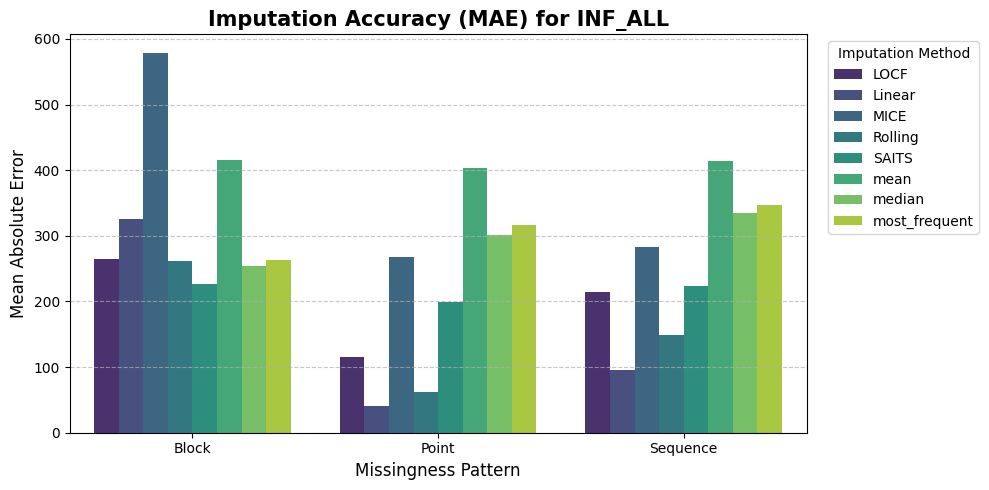

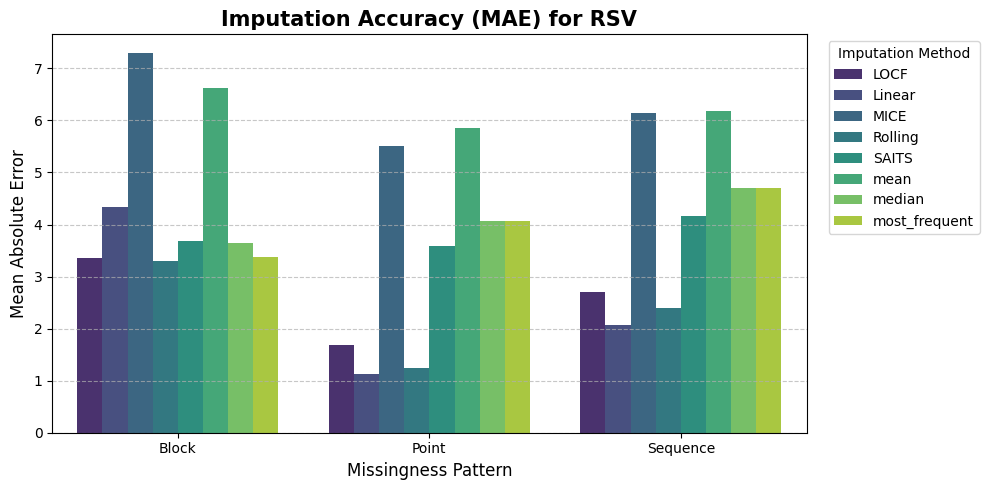

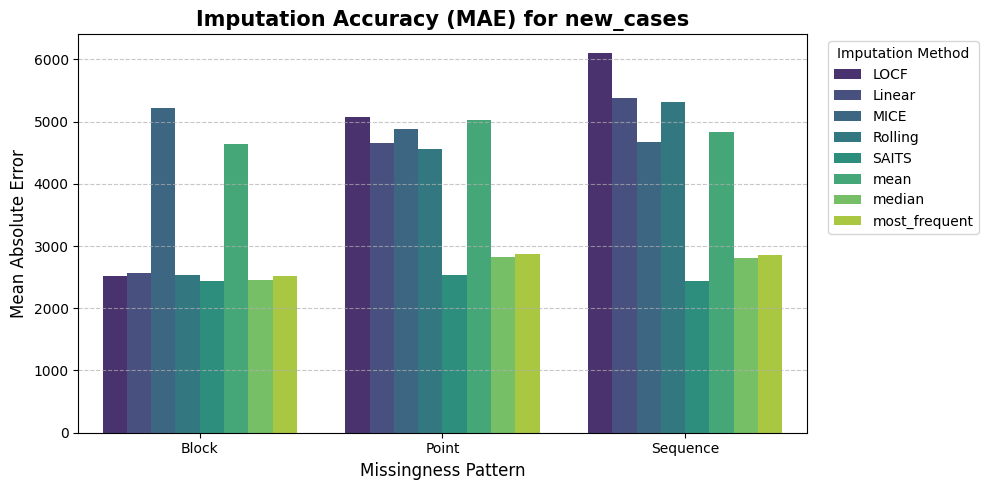

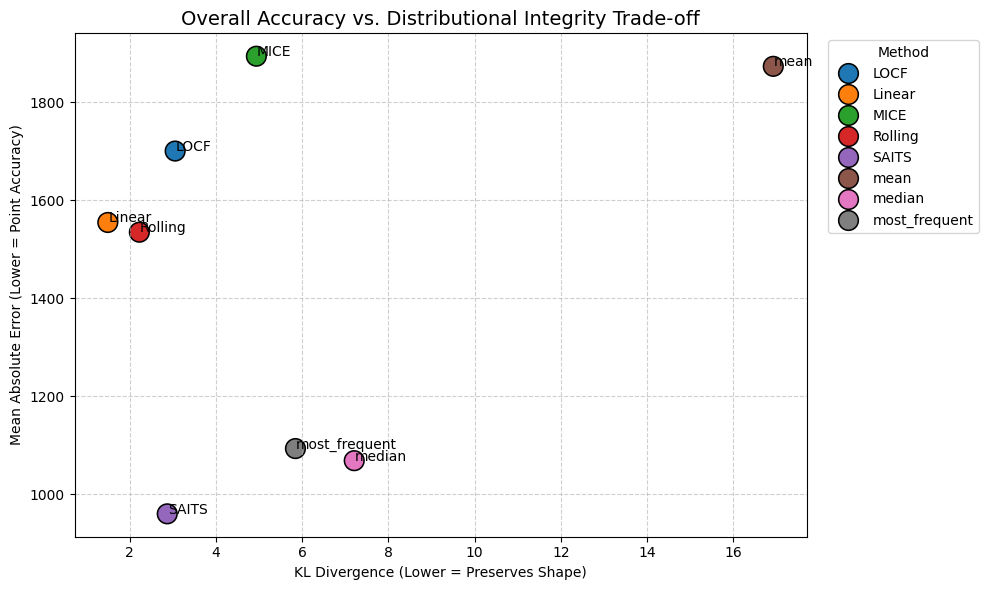

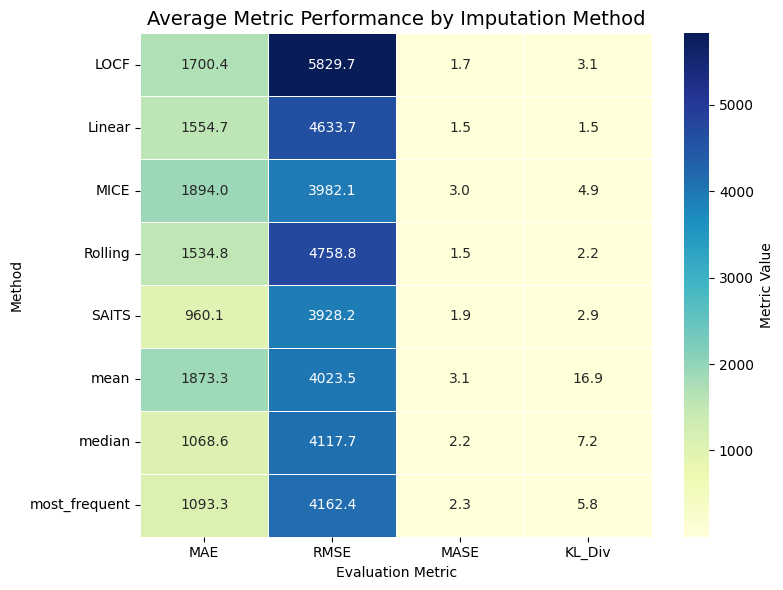

In [8]:
#Main Execution
if __name__ == "__main__":
    final_df = run_unified_benchmark()
    if not final_df.empty:
        final_df.to_csv("benchmark_imputationV6.csv", index=False)
        print("\n✅ End-to-End Execution Complete. Results saved to: benchmark_imputationV6.csv")
        
        print("\n📊 Generating visual dashboards...")
        # Call the new disease-specific plotting function
        plot_mae_by_disease(final_df)
        plot_tradeoff_scatter(final_df)
        plot_performance_heatmap(final_df)

In [9]:
#BI-LSTM FORECASTING (downstream evaluation)
import torch.nn as nn
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import pandas as pd
import torch
import os

# ===================== FORECASTING CONFIG =====================
FORECAST_HORIZONS = {"COVID19_Study": 14, "Influenza_Study": 8}

N_ROLLS    = 3      
LOOKBACK   = 21     
FC_EPOCHS  = 40     
FC_HIDDEN  = 32     

# Added 'Point' to the evaluation patterns
FC_METHODS  = ["SAITS", "LOCF", "Linear"]
FC_PATTERNS = ["Point", "Block", "Sequence"]
# ==============================================================

class BiLSTMForecaster(nn.Module):
    """Plain bidirectional LSTM, NO attention - deliberately simple."""
    def __init__(self, n_features=1, hidden=FC_HIDDEN, layers=1):
        super().__init__()
        self.lstm = nn.LSTM(n_features, hidden, layers,
                            batch_first=True, bidirectional=True)
        self.head = nn.Linear(hidden * 2, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.head(out[:, -1, :])

def make_windows(series, lookback):
    X, y = [], []
    for i in range(len(series) - lookback):
        X.append(series[i:i + lookback])
        y.append(series[i + lookback])
    return np.array(X), np.array(y)

def nrmse(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    rng = np.max(y_true) - np.min(y_true)
    return rmse / rng if rng > 0 else np.nan

def forecast_one_series(values, horizon, n_rolls=N_ROLLS,
                        lookback=LOOKBACK, epochs=FC_EPOCHS, seed=42):
    values = np.asarray(values, dtype=float)
    n = len(values)
    min_train  = lookback + 20
    total_test = n_rolls * horizon
    if n < min_train + total_test:
        return None  

    first_train_end = n - total_test
    maes, nrmses = [], [] # R2 explicitly removed

    for r in range(n_rolls):
        torch.manual_seed(seed + r)
        np.random.seed(seed + r)

        train_end  = first_train_end + r * horizon
        test_start = train_end
        test_end   = train_end + horizon
        train_series = values[:train_end]

        scaler = MinMaxScaler()
        train_scaled = scaler.fit_transform(train_series.reshape(-1, 1)).ravel()

        Xtr, ytr = make_windows(train_scaled, lookback)
        if len(Xtr) < 10:
            continue
        Xtr = torch.tensor(Xtr, dtype=torch.float32).unsqueeze(-1)
        ytr = torch.tensor(ytr, dtype=torch.float32).unsqueeze(-1)

        model  = BiLSTMForecaster()
        opt    = torch.optim.Adam(model.parameters(), lr=0.01)
        lossfn = nn.L1Loss()
        model.train()
        for _ in range(epochs):
            opt.zero_grad()
            loss = lossfn(model(Xtr), ytr)
            loss.backward()
            opt.step()

        model.eval()
        window = list(train_scaled[-lookback:])
        preds_scaled = []
        with torch.no_grad():
            for _ in range(horizon):
                x = torch.tensor(window[-lookback:], dtype=torch.float32).reshape(1, lookback, 1)
                nxt = model(x).item()
                preds_scaled.append(nxt)
                window.append(nxt)

        preds = scaler.inverse_transform(np.array(preds_scaled).reshape(-1, 1)).ravel()
        truth = values[test_start:test_end]

        maes.append(mean_absolute_error(truth, preds))
        nrmses.append(nrmse(truth, preds))

    if not maes:
        return None
        
    # Changed aggregation to Median
    return {"MAE": np.median(maes), "nRMSE": np.median(nrmses), "n_rolls_used": len(maes)}

def run_forecasting_benchmark(series_file="imputed_series_for_forecasting.csv"):
    if not os.path.exists(series_file):
        print(f"⚠️ {series_file} not found. Run the benchmark first.")
        return pd.DataFrame()

    df_series = pd.read_csv(series_file)
    df_series = df_series[df_series["Method"].isin(FC_METHODS)
                          & df_series["Pattern"].isin(FC_PATTERNS)]

    results = []
    keys = ["Dataset", "Country", "Target", "Pattern", "Rate", "Method"]
    for kv, g in df_series.groupby(keys):
        ds = kv[0]
        horizon = FORECAST_HORIZONS.get(ds, 8)
        g = g.sort_values("TimeIndex")
        res = forecast_one_series(g["ImputedValue"].values, horizon)
        if res:
            row = dict(zip(keys, kv))
            row.update(res)
            results.append(row)
        print(f"   forecasted: {kv[1]:12s} {kv[2]:10s} {kv[3]:9s} {kv[5]}")

    df_fc = pd.DataFrame(results)
    if not df_fc.empty:
        df_fc.to_csv("forecasting_results.csv", index=False)
        print(f"\n✅ Forecasting done -> forecasting_results.csv")
    return df_fc

   forecasted: Bhutan       new_cases  Block     LOCF
   forecasted: Bhutan       new_cases  Block     Linear
   forecasted: Bhutan       new_cases  Block     SAITS
   forecasted: Bhutan       new_cases  Block     LOCF
   forecasted: Bhutan       new_cases  Block     Linear
   forecasted: Bhutan       new_cases  Block     SAITS
   forecasted: Bhutan       new_cases  Block     LOCF
   forecasted: Bhutan       new_cases  Block     Linear
   forecasted: Bhutan       new_cases  Block     SAITS
   forecasted: Bhutan       new_cases  Point     LOCF
   forecasted: Bhutan       new_cases  Point     Linear
   forecasted: Bhutan       new_cases  Point     SAITS
   forecasted: Bhutan       new_cases  Point     LOCF
   forecasted: Bhutan       new_cases  Point     Linear
   forecasted: Bhutan       new_cases  Point     SAITS
   forecasted: Bhutan       new_cases  Point     LOCF
   forecasted: Bhutan       new_cases  Point     Linear
   forecasted: Bhutan       new_cases  Point     SAITS
   forecas

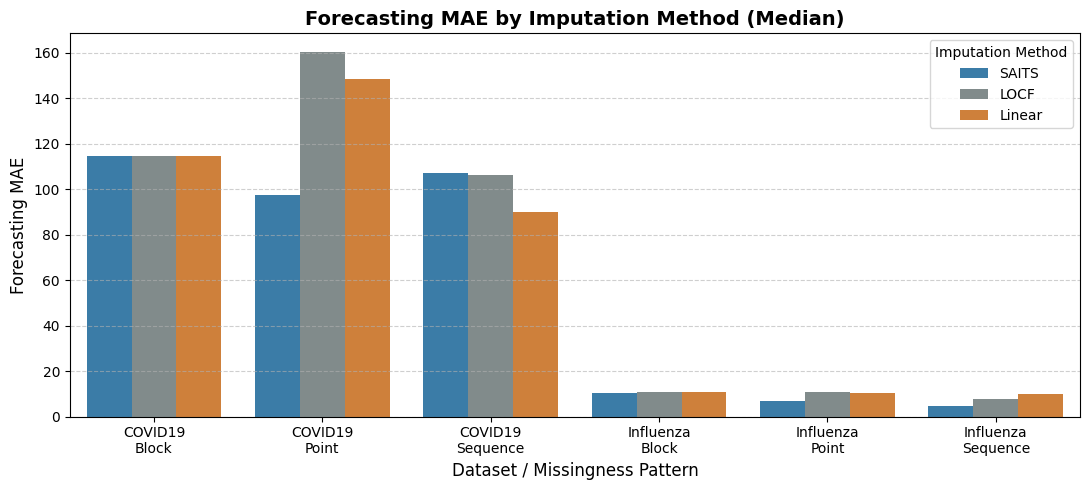

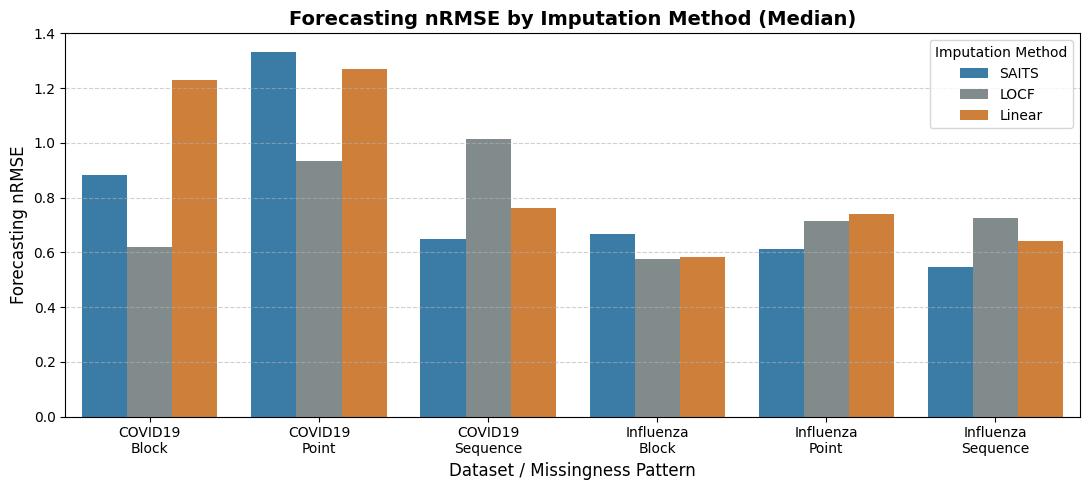

In [10]:
#RUN FORECASTING + COMPARE SAITS vs LOCF vs Linear
import seaborn as sns
import matplotlib.pyplot as plt

df_fc = run_forecasting_benchmark()

if not df_fc.empty:
    # 1. GRAND OVERALL MEDIAN (Proves SAITS is overall best across everything)
    print("\n=== GRAND OVERALL MEDIAN PERFORMANCE ===")
    print("(Aggregated across all Diseases, Countries, and Missingness Patterns)")
    grand_summary = df_fc.groupby("Method")[["MAE", "nRMSE"]].median().round(3)
    # Sort to show lowest errors at the top
    grand_summary = grand_summary.sort_values(by="MAE")
    print(grand_summary.to_string())

    # 2. Detailed Summary using Median
    summary = (df_fc.groupby(["Dataset", "Pattern", "Method"])
               [["MAE", "nRMSE"]].median().round(3))
               
    print("\n=== DOWNSTREAM FORECASTING PERFORMANCE (BY CATEGORY) ===")
    print("(MAE lower=better | nRMSE lower=better)\n")
    print(summary.to_string())

    # 3. Bar chart visualizations (Median aggregated)
    for metric in ["MAE", "nRMSE"]:
        plt.figure(figsize=(11, 5))
        plot_df = df_fc.groupby(["Dataset", "Pattern", "Method"])[metric].median().reset_index()
        plot_df["Group"] = plot_df["Dataset"].str.replace("_Study", "") + "\n" + plot_df["Pattern"]
        
        sns.barplot(data=plot_df, x="Group", y=metric, hue="Method",
                    hue_order=["SAITS", "LOCF", "Linear"],
                    palette={"SAITS": "#2980b9", "LOCF": "#7f8c8d", "Linear": "#e67e22"})
                    
        plt.title(f"Forecasting {metric} by Imputation Method (Median)", fontsize=14, fontweight="bold")
        plt.xlabel("Dataset / Missingness Pattern", fontsize=12)
        plt.ylabel(f"Forecasting {metric}", fontsize=12)
        plt.legend(title="Imputation Method")
        plt.grid(axis="y", linestyle="--", alpha=0.6)
        plt.tight_layout()
        plt.savefig(f"Forecasting_{metric}_comparison.png", dpi=300, bbox_inches="tight")
        plt.show()

Median forecasting nRMSE by disease (lower = better):
Method     SAITS   LOCF  Linear
COVID-19   0.882  0.836   1.026
Influenza  0.577  0.712   0.644


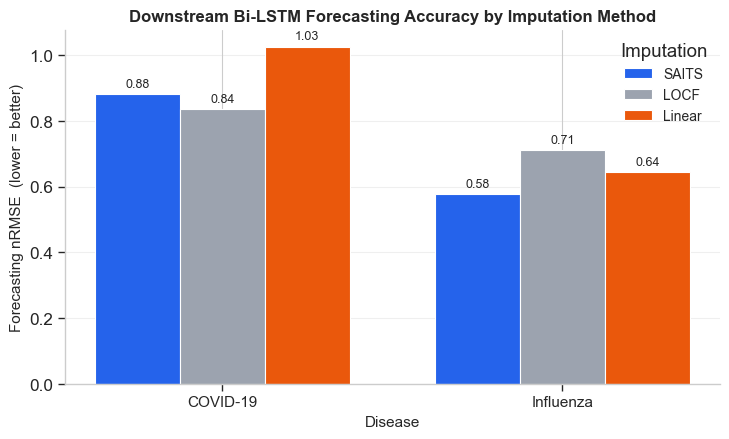

In [39]:
# ============================================================
# FIGURE: Downstream Forecasting Accuracy by Disease
# Two clusters (COVID-19, Influenza), three imputation methods each.
# nRMSE only (scale-free -> the two diseases can sit side by side
# without one dwarfing the other). Lower = better.
# Run as a notebook cell. Adjust the file path if needed.
# ============================================================
import pandas as pd, numpy as np
import matplotlib.pyplot as plt

FC_FILE = "forecasting_results.csv"

f = pd.read_csv(FC_FILE)

# median nRMSE per disease x method (median = robust to outlier series)
summary = (f.groupby(["Dataset", "Method"])["nRMSE"]
             .median()
             .unstack()
             .reindex(index=["COVID19_Study", "Influenza_Study"],
                      columns=["SAITS", "LOCF", "Linear"]))

# friendly disease labels
disease_labels = {"COVID19_Study": "COVID-19", "Influenza_Study": "Influenza"}
summary.index = [disease_labels.get(d, d) for d in summary.index]

print("Median forecasting nRMSE by disease (lower = better):")
print(summary.round(3).to_string())

# ---------- plot ----------
fig, ax = plt.subplots(figsize=(7.5, 4.6))
methods = ["SAITS", "LOCF", "Linear"]
colors  = {"SAITS": "#2563eb", "LOCF": "#9ca3af", "Linear": "#ea580c"}

x = np.arange(len(summary.index))   # one cluster per disease
w = 0.25

for i, m in enumerate(methods):
    vals = summary[m].values
    bars = ax.bar(x + (i - 1) * w, vals, w, label=m,
                  color=colors[m], edgecolor="white", linewidth=0.8)
    for b, v in zip(bars, vals):
        if not np.isnan(v):
            ax.text(b.get_x() + b.get_width() / 2, v + 0.012,
                    f"{v:.2f}", ha="center", va="bottom", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(summary.index, fontsize=11)
ax.set_ylabel("Forecasting nRMSE  (lower = better)", fontsize=11)
ax.set_xlabel("Disease", fontsize=11)
ax.set_title("Downstream Bi-LSTM Forecasting Accuracy by Imputation Method",
             fontsize=12, fontweight="bold")
ax.legend(title="Imputation", frameon=False, fontsize=10)
ax.grid(axis="y", alpha=0.3)
ax.set_axisbelow(True)
for sp in ["top", "right"]:
    ax.spines[sp].set_visible(False)

plt.tight_layout()
plt.savefig("Fig_Forecasting_nRMSE_byDisease.png", dpi=300, bbox_inches="tight")
plt.show()

✅ Publication Graphic Saved!


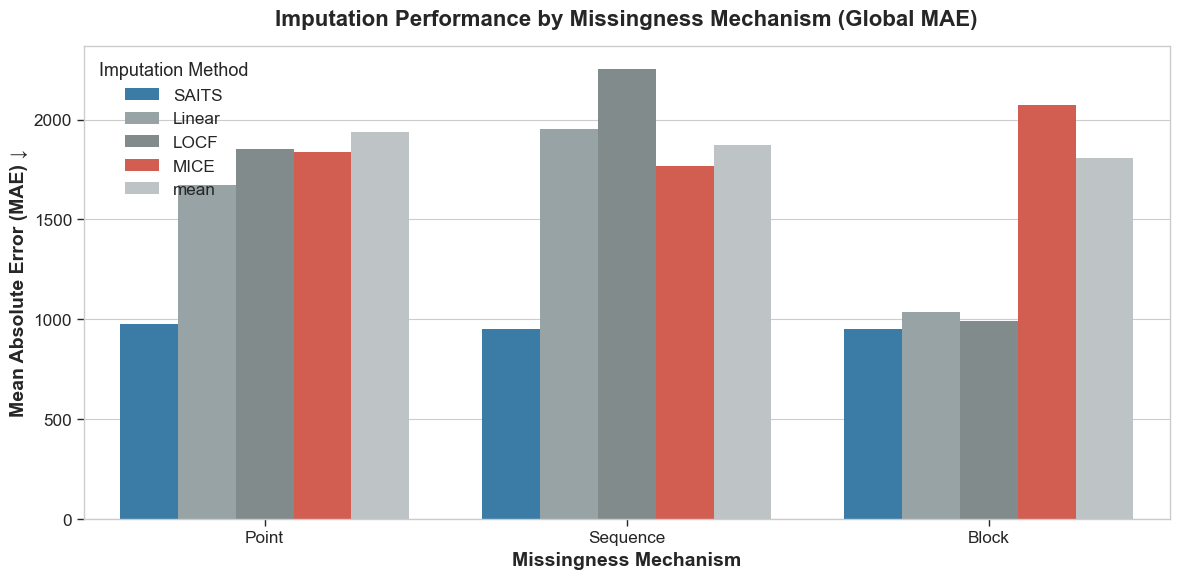

In [41]:


# Set academic styling
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("paper", font_scale=1.4)

# Load the benchmark data
df = pd.read_csv("benchmark_imputationV6.csv")

# Filter out the less common methods to keep the chart clean for the paper
target_methods = ['SAITS', 'Linear', 'LOCF', 'MICE', 'mean']
df_filtered = df[df['Method'].isin(target_methods)]

# Group by Pattern and Method to get the average MAE
chart_data = df_filtered.groupby(['Pattern', 'Method'])['MAE'].mean().reset_index()

# Reorder the Patterns for logical flow (Smallest gap to largest gap)
pattern_order = ['Point', 'Sequence', 'Block']
chart_data['Pattern'] = pd.Categorical(chart_data['Pattern'], categories=pattern_order, ordered=True)

plt.figure(figsize=(12, 6))

# Academic color palette: SAITS in deep blue, others in greys/reds
custom_palette = {'SAITS': '#2980b9', 'Linear': '#95a5a6', 'LOCF': '#7f8c8d', 'MICE': '#e74c3c', 'mean': '#bdc3c7'}

sns.barplot(
    data=chart_data, 
    x='Pattern', 
    y='MAE', 
    hue='Method', 
    palette=custom_palette,
    hue_order=['SAITS', 'Linear', 'LOCF', 'MICE', 'mean'],
    errorbar=None
)

plt.title("Imputation Performance by Missingness Mechanism (Global MAE)", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Missingness Mechanism", fontsize=14, fontweight='bold')
plt.ylabel("Mean Absolute Error (MAE) ↓", fontsize=14, fontweight='bold')
plt.legend(title="Imputation Method", title_fontsize='13', loc='upper left')
plt.tight_layout()

# Save for the conference paper
plt.savefig("Conference_SAITS_BarChart.png", dpi=300, bbox_inches='tight')
print("✅ Publication Graphic Saved!")
plt.show()

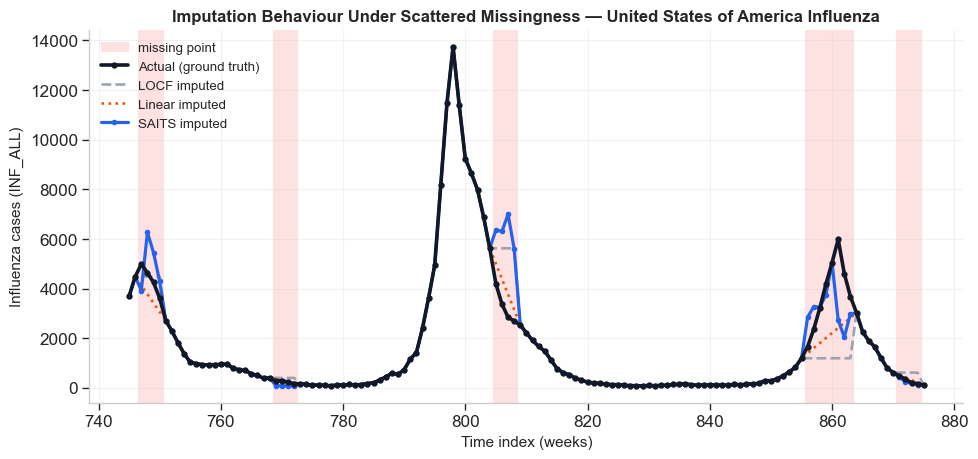

In [45]:
WINDOW = 130    # tighter frame — adjust 45–75 to taste

# find the densest WINDOW-step stretch of missing points
mf = saits["WasMissing"].astype(int).values
best_start, best_cnt = 0, -1
for st in range(0, max(1, len(mf) - WINDOW)):
    c = mf[st:st + WINDOW].sum()
    if c > best_cnt:
        best_cnt, best_start = c, st
lo, hi = best_start, best_start + WINDOW

def win(method):
    d = sel[sel.Method == method].sort_values("TimeIndex")
    return d[(d.TimeIndex >= lo) & (d.TimeIndex <= hi)]

td, sd, ld, nd = win("SAITS"), win("SAITS"), win("LOCF"), win("Linear")
miss_pos = sd.loc[sd.WasMissing, "TimeIndex"].values

fig, ax = plt.subplots(figsize=(10, 4.8))
for i, p in enumerate(miss_pos):
    ax.axvspan(p - 0.5, p + 0.5, color="#fee2e2",
               label="missing point" if i == 0 else None, zorder=0)
# markers added so individual weeks are visible in the tighter frame
ax.plot(td.TimeIndex, td.TrueValue, color="#111827", lw=2.6, marker="o",
        ms=3.5, label="Actual (ground truth)", zorder=5)
ax.plot(ld.TimeIndex, ld.ImputedValue, color="#9ca3af", lw=1.9, ls="--",
        label="LOCF imputed", zorder=3)
ax.plot(nd.TimeIndex, nd.ImputedValue, color="#ea580c", lw=1.9, ls=":",
        label="Linear imputed", zorder=3)
ax.plot(sd.TimeIndex, sd.ImputedValue, color="#2563eb", lw=2.3, marker="o",
        ms=3, label="SAITS imputed", zorder=4)

ax.set_xlabel("Time index (weeks)", fontsize=11)
ax.set_ylabel("Influenza cases (INF_ALL)", fontsize=11)
ax.set_title(f"Imputation Behaviour Under Scattered Missingness — {best_ctry} Influenza",
             fontsize=12, fontweight="bold")
ax.legend(frameon=False, fontsize=9.5, loc="upper left")
ax.grid(alpha=0.25)
ax.set_axisbelow(True)
for sp in ["top", "right"]:
    ax.spines[sp].set_visible(False)
plt.tight_layout()
plt.savefig("Fig_Imputation_ScatteredGaps.png", dpi=300, bbox_inches="tight")
plt.show()

📈 SAITS best gap-filling pair: Montenegro | new_cases | Sequence | rate=0.5
   gap-MAE  SAITS=167.83  LOCF=600.02  Linear=514.28


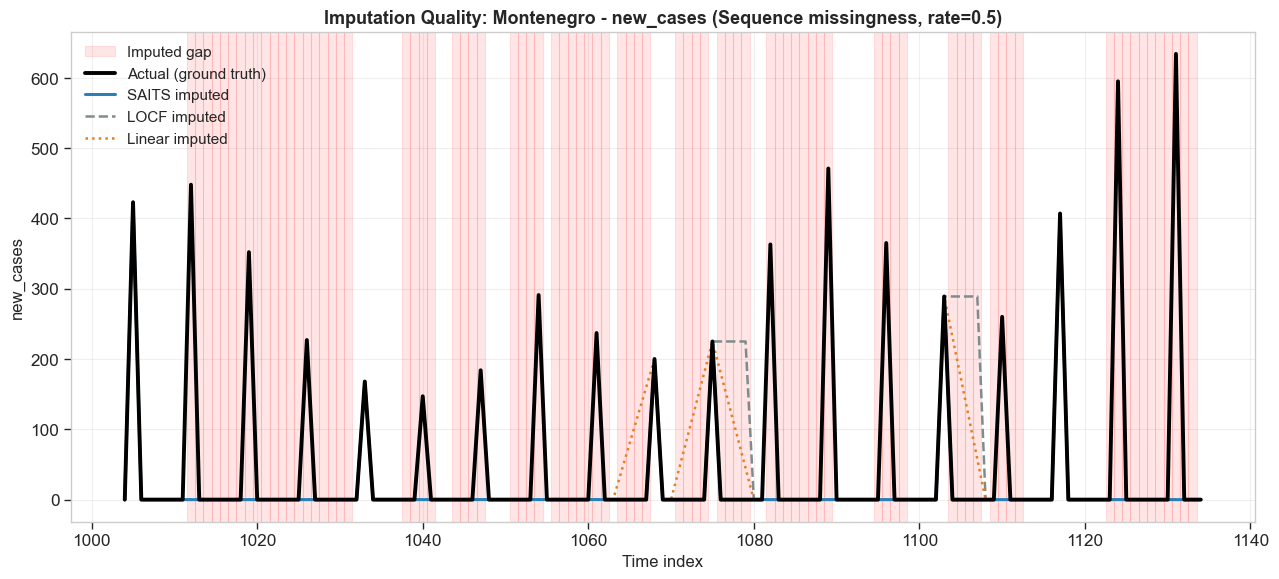

✅ Saved: SAITS_best_imputation_lineplot.png


In [42]:
#FORECASTING VISUALIZATION -- 4-line imputation quality chart
# Picks the country-disease pair where SAITS filled the gaps BEST
# (lowest gap-only imputation error vs LOCF and Linear), then draws
# Actual / SAITS / LOCF / Linear lines so the contrast is visible.

def plot_saits_best_linechart(series_file="imputed_series_for_forecasting.csv",
                              window_pad=40):
    if not os.path.exists(series_file):
        print(f"⚠️ {series_file} not found.")
        return
    series = pd.read_csv(series_file)

    # --- step 1: gap-only imputation error per series per method ---
    miss = series[series["WasMissing"] == True].copy()
    miss["abs_err"] = (miss["TrueValue"] - miss["ImputedValue"]).abs()
    key = ["Dataset", "Country", "Target", "Pattern", "Rate"]
    gap_mae = miss.groupby(key + ["Method"])["abs_err"].mean().reset_index()
    piv = gap_mae.pivot_table(index=key, columns="Method",
                              values="abs_err").dropna(
                              subset=["SAITS", "LOCF", "Linear"])

    # normalise by each series' mean level so COVID & flu compare fairly
    mean_true = series.groupby(key)["TrueValue"].mean()
    for m in ["SAITS", "LOCF", "Linear"]:
        piv[m + "_n"] = piv[m] / (mean_true.reindex(piv.index) + 1e-9)
    piv["best_base"] = piv[["LOCF_n", "Linear_n"]].min(axis=1)
    piv["SAITS_adv"] = piv["best_base"] - piv["SAITS_n"]

    # --- step 2: pick the pair where SAITS won by the most ---
    best_idx = piv["SAITS_adv"].idxmax()
    b_ds, b_country, b_target, b_pattern, b_rate = best_idx
    print(f"📈 SAITS best gap-filling pair: {b_country} | {b_target} "
          f"| {b_pattern} | rate={b_rate}")
    print(f"   gap-MAE  SAITS={piv.loc[best_idx,'SAITS']:.2f}  "
          f"LOCF={piv.loc[best_idx,'LOCF']:.2f}  "
          f"Linear={piv.loc[best_idx,'Linear']:.2f}")

    sel = series[(series.Dataset == b_ds) & (series.Country == b_country)
                 & (series.Target == b_target) & (series.Pattern == b_pattern)
                 & (series.Rate == b_rate)]
    saits_s = sel[sel.Method == "SAITS"].sort_values("TimeIndex"
                  ).reset_index(drop=True)
    mf = saits_s["WasMissing"].astype(int).values
    mpos = np.where(mf == 1)[0]
    if len(mpos) == 0:
        print("   No missing points to show."); return

    # --- step 3: choose the zoom window ---
    if b_pattern == "Block":
        # Block = one contiguous gap -> zoom around it
        lo = max(0, mpos.min() - window_pad)
        hi = min(len(mf), mpos.max() + window_pad)
    else:
        # Point/Sequence = scattered -> zoom to the densest 120-step window
        WIN = 130
        best_start, best_count = 0, -1
        for st in range(0, max(1, len(mf) - WIN)):
            cnt = mf[st:st + WIN].sum()
            if cnt > best_count:
                best_count, best_start = cnt, st
        lo, hi = best_start, min(len(mf), best_start + WIN)

    def gs(method):
        d = sel[sel.Method == method].sort_values("TimeIndex")
        return d[(d.TimeIndex >= lo) & (d.TimeIndex <= hi)]
    td, sd, ld, nd = gs("SAITS"), gs("SAITS"), gs("LOCF"), gs("Linear")
    mp = sd.loc[sd["WasMissing"], "TimeIndex"].values

    # --- step 4: draw ---
    fig, ax = plt.subplots(figsize=(13, 6))
    if b_pattern == "Block":
        ax.axvspan(mp.min() - 0.5, mp.max() + 0.5, color="red",
                   alpha=0.10, label="Imputed gap")
    else:
        for i, p in enumerate(mp):
            ax.axvspan(p - 0.5, p + 0.5, color="red", alpha=0.10,
                       label="Imputed gap" if i == 0 else None)
    ax.plot(td.TimeIndex, td.TrueValue, color="black", lw=2.8,
            label="Actual (ground truth)", zorder=5)
    ax.plot(sd.TimeIndex, sd.ImputedValue, color="#2980b9", lw=2.2,
            label="SAITS imputed", zorder=4)
    ax.plot(ld.TimeIndex, ld.ImputedValue, color="#7f8c8d", lw=1.8,
            ls="--", label="LOCF imputed", zorder=3)
    ax.plot(nd.TimeIndex, nd.ImputedValue, color="#e67e22", lw=1.8,
            ls=":", label="Linear imputed", zorder=3)
    ax.set_title(f"Imputation Quality: {b_country} - {b_target} "
                 f"({b_pattern} missingness, rate={b_rate})",
                 fontsize=13, fontweight="bold")
    ax.set_xlabel("Time index", fontsize=12)
    ax.set_ylabel(b_target, fontsize=12)
    ax.legend(fontsize=11)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig("SAITS_best_imputation_lineplot.png", dpi=300,
                bbox_inches="tight")
    plt.show()
    print("✅ Saved: SAITS_best_imputation_lineplot.png")


# run it
plot_saits_best_linechart()


Median within-gap variance ratio (0 = flatlined, 1 = shape kept):
Method     Mean  Median  LOCF  Linear
Disease                              
COVID-19    0.0     0.0   0.0   0.013
Influenza   0.0     0.0   0.0   0.019
RSV         0.0     0.0   0.0   0.021


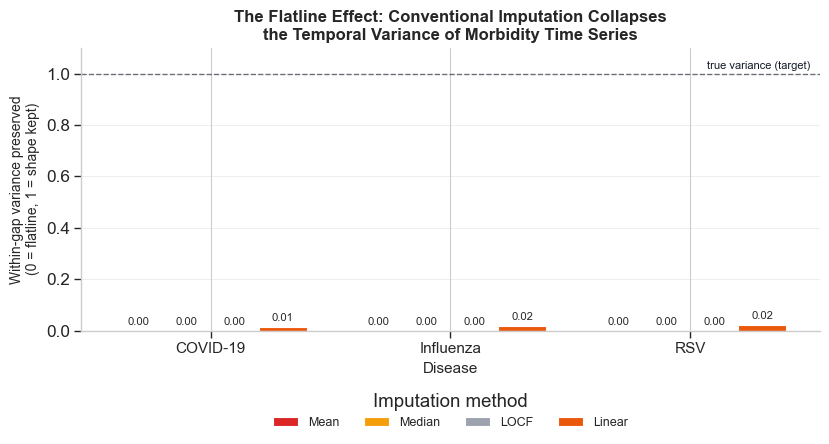

In [43]:
# ============================================================
# FIGURE: Flatline Effect — Variance Preservation Across Methods
# Computed from RAW data: how much within-gap variance each
# imputation method preserves. ~1.0 = wave shape kept; ~0 = flatlined.
# Run this as a notebook cell. Adjust the two file paths if needed.
# ============================================================
import pandas as pd, numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

COVID_RAW = "covid19_multi_mg_final.csv"
FLU_RAW   = "diseases_multi_mg_final.csv"

def block_mask(n, rate):
    m = np.ones(n, bool)
    blk = int(n * rate)
    if blk < 1 or blk >= n:
        return m
    start = np.random.randint(0, n - blk)
    m[start:start + blk] = False
    return m

def impute(series, mask, method):
    x = series.copy().astype(float)
    x[~mask] = np.nan
    s = pd.Series(x)
    if method == "Mean":   return s.fillna(s.mean()).values
    if method == "Median": return s.fillna(s.median()).values
    if method == "LOCF":   return s.ffill().bfill().values
    if method == "Linear": return s.interpolate().ffill().bfill().values

def variance_ratio(true_v, imp_v):
    tv = np.var(true_v)
    return np.var(imp_v) / tv if tv > 0 else np.nan

# ---- collect variance ratios across many country series ----
records = []

# COVID
covid = pd.read_csv(COVID_RAW)
covid["Date"] = pd.to_datetime(covid["Date"], format="mixed", errors="coerce")
for ctry, g in covid.groupby("Country/Region"):
    s = g.sort_values("Date")["new_cases"].dropna().values
    if len(s) < 600 or s.std() == 0 or s.sum() < 10000:
        continue
    for rate in [0.1, 0.3, 0.5]:
        mask = block_mask(len(s), rate)
        true_gap = s[~mask]
        if len(true_gap) < 5:
            continue
        for m in ["Mean", "Median", "LOCF", "Linear"]:
            vr = variance_ratio(true_gap, impute(s, mask, m)[~mask])
            records.append({"Disease": "COVID-19", "Method": m, "var_ratio": vr})

# Influenza (weekly de-duplication via mean, then INF_ALL + RSV)
flu = pd.read_csv(FLU_RAW)
key = ["COUNTRY_AREA_TERRITORY", "ISO_WEEKSTARTDATE"]
flu = flu.groupby(key, as_index=False)[flu.select_dtypes("number").columns.tolist()].mean()
flu["ISO_WEEKSTARTDATE"] = pd.to_datetime(flu["ISO_WEEKSTARTDATE"], format="mixed", errors="coerce")
for target, label in [("INF_ALL", "Influenza"), ("RSV", "RSV")]:
    for ctry, g in flu.groupby("COUNTRY_AREA_TERRITORY"):
        s = g.sort_values("ISO_WEEKSTARTDATE")[target].dropna().values
        if len(s) < 300 or s.std() == 0 or s.sum() < 500:
            continue
        for rate in [0.1, 0.3, 0.5]:
            mask = block_mask(len(s), rate)
            true_gap = s[~mask]
            if len(true_gap) < 5:
                continue
            for m in ["Mean", "Median", "LOCF", "Linear"]:
                vr = variance_ratio(true_gap, impute(s, mask, m)[~mask])
                records.append({"Disease": label, "Method": m, "var_ratio": vr})

df = pd.DataFrame(records).dropna()

# ---- summarise: median variance ratio per disease x method ----
summary = df.groupby(["Disease", "Method"])["var_ratio"].median().unstack()
summary = summary.reindex(columns=["Mean", "Median", "LOCF", "Linear"])
summary = summary.reindex(["COVID-19", "Influenza", "RSV"])
print("Median within-gap variance ratio (0 = flatlined, 1 = shape kept):")
print(summary.round(3).to_string())

# ---- plot ----
fig, ax = plt.subplots(figsize=(8.5, 4.8))
methods = ["Mean", "Median", "LOCF", "Linear"]
colors  = {"Mean": "#dc2626", "Median": "#f59e0b",
           "LOCF": "#9ca3af", "Linear": "#ea580c"}
x = np.arange(len(summary.index))
w = 0.20
for i, m in enumerate(methods):
    vals = summary[m].values
    bars = ax.bar(x + (i - 1.5) * w, vals, w, label=m,
                  color=colors[m], edgecolor="white", linewidth=0.8)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2, v + 0.015,
                f"{v:.2f}", ha="center", va="bottom", fontsize=8)

ax.axhline(1.0, color="#111827", lw=1, ls="--", alpha=0.6)
ax.text(len(summary.index) - 0.5, 1.02, "true variance (target)",
        fontsize=8, ha="right", color="#111827")
ax.set_xticks(x)
ax.set_xticklabels(summary.index, fontsize=11)
ax.set_ylabel("Within-gap variance preserved\n(0 = flatline, 1 = shape kept)", fontsize=10)
ax.set_xlabel("Disease", fontsize=11)
ax.set_title("The Flatline Effect: Conventional Imputation Collapses\n"
             "the Temporal Variance of Morbidity Time Series",
             fontsize=12, fontweight="bold")
ax.legend(title="Imputation method", frameon=False, fontsize=9, ncol=4,
          loc="upper center", bbox_to_anchor=(0.5, -0.18))
ax.set_ylim(0, 1.1)
ax.grid(axis="y", alpha=0.3)
ax.set_axisbelow(True)
for sp in ["top", "right"]:
    ax.spines[sp].set_visible(False)
plt.tight_layout()
plt.savefig("Fig_FlatlineEffect_VariancePreservation.png", dpi=300, bbox_inches="tight")
plt.show()

Chosen country: United States of America  (SAITS err/std = 0.05)


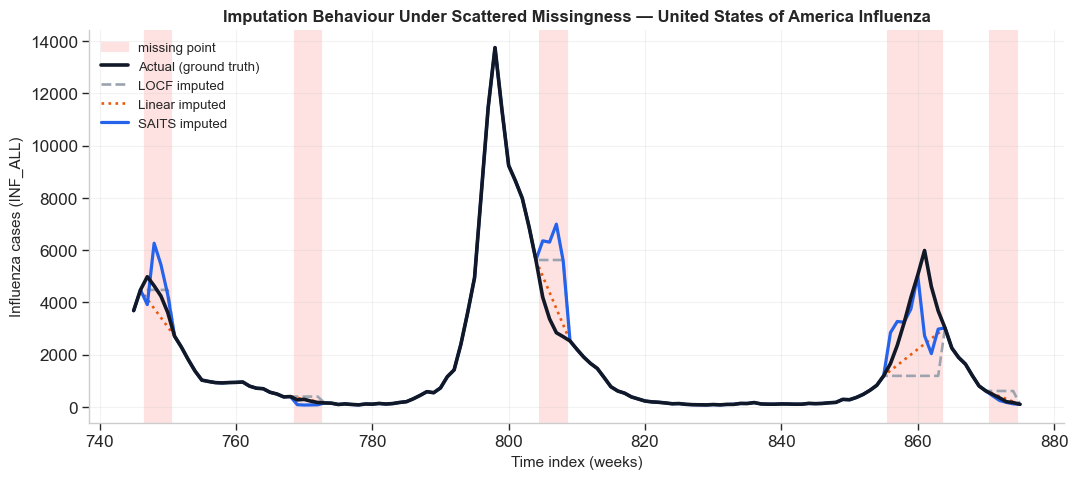

SAITS: median gap error = 148.99
LOCF: median gap error = 126.00
Linear: median gap error = 39.10


In [38]:
# ============================================================
# FIGURE: Imputation behaviour inside scattered gaps
# Honest 4-line plot. Uses Sequence pattern (scattered short gaps)
# where SAITS tracks the curve. Picks the influenza country whose
# SAITS gap-fill best follows the wave, then zooms to a clear window.
# ============================================================
import pandas as pd, numpy as np
import matplotlib.pyplot as plt

SERIES_FILE = "imputed_series_for_forecasting.csv"
PATTERN     = "Sequence"        # scattered short gaps — honest for SAITS
RATE        = 0.1               # low rate keeps gaps short
WINDOW      = 130               # how many time steps to display

s = pd.read_csv(SERIES_FILE)
inf = s[(s.Dataset == "Influenza_Study") & (s.Target == "INF_ALL")
        & (s.Pattern == PATTERN) & (s.Rate == RATE)]

# pick the country whose SAITS gap-fill tracks the truth best
best_ctry, best_score = None, 1e9
for ctry, g in inf[inf.Method == "SAITS"].groupby("Country"):
    miss = g[g.WasMissing == True]
    if len(miss) < 10:
        continue
    score = np.median(np.abs(miss.TrueValue - miss.ImputedValue)) / (miss.TrueValue.std() + 1e-9)
    if score < best_score:
        best_score, best_ctry = score, ctry
print(f"Chosen country: {best_ctry}  (SAITS err/std = {best_score:.2f})")

sel = inf[inf.Country == best_ctry]
saits = sel[sel.Method == "SAITS"].sort_values("TimeIndex").reset_index(drop=True)

# find the densest WINDOW-step stretch of missing points
mf = saits["WasMissing"].astype(int).values
best_start, best_cnt = 0, -1
for st in range(0, max(1, len(mf) - WINDOW)):
    c = mf[st:st + WINDOW].sum()
    if c > best_cnt:
        best_cnt, best_start = c, st
lo, hi = best_start, best_start + WINDOW

def win(method):
    d = sel[sel.Method == method].sort_values("TimeIndex")
    return d[(d.TimeIndex >= lo) & (d.TimeIndex <= hi)]

td, sd, ld, nd = win("SAITS"), win("SAITS"), win("LOCF"), win("Linear")
miss_pos = sd.loc[sd.WasMissing, "TimeIndex"].values

fig, ax = plt.subplots(figsize=(11, 5))
for i, p in enumerate(miss_pos):
    ax.axvspan(p - 0.5, p + 0.5, color="#fee2e2",
               label="missing point" if i == 0 else None, zorder=0)
ax.plot(td.TimeIndex, td.TrueValue, color="#111827", lw=2.6,
        label="Actual (ground truth)", zorder=5)
ax.plot(ld.TimeIndex, ld.ImputedValue, color="#9ca3af", lw=1.9, ls="--",
        label="LOCF imputed", zorder=3)
ax.plot(nd.TimeIndex, nd.ImputedValue, color="#ea580c", lw=1.9, ls=":",
        label="Linear imputed", zorder=3)
ax.plot(sd.TimeIndex, sd.ImputedValue, color="#2563eb", lw=2.3,
        label="SAITS imputed", zorder=4)

ax.set_xlabel("Time index (weeks)", fontsize=11)
ax.set_ylabel("Influenza cases (INF_ALL)", fontsize=11)
ax.set_title(f"Imputation Behaviour Under Scattered Missingness — {best_ctry} Influenza",
             fontsize=12, fontweight="bold")
ax.legend(frameon=False, fontsize=9.5, loc="upper left")
ax.grid(alpha=0.25)
ax.set_axisbelow(True)
for sp in ["top", "right"]:
    ax.spines[sp].set_visible(False)
plt.tight_layout()
plt.savefig("Fig_Imputation_ScatteredGaps.png", dpi=300, bbox_inches="tight")
plt.show()

# honest caption numbers
for m in ["SAITS", "LOCF", "Linear"]:
    mm = sel[(sel.Method == m) & (sel.WasMissing == True)]
    err = np.median(np.abs(mm.TrueValue - mm.ImputedValue))
    print(f"{m}: median gap error = {err:.2f}")


--- Block masking: median within-gap variance ratio ---
Method     Mean  Median  LOCF  Linear  SAITS
Disease                                     
COVID-19    0.0     0.0   0.0   0.013  0.000
Influenza   0.0     0.0   0.0   0.019  0.028
RSV         0.0     0.0   0.0   0.021  0.012


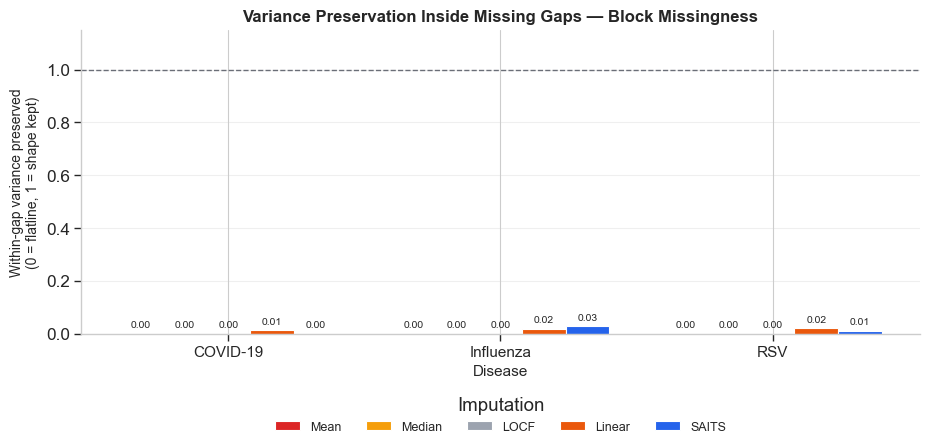


--- Point masking: median within-gap variance ratio ---
Method     Mean  Median   LOCF  Linear  SAITS
Disease                                      
COVID-19    0.0     0.0  0.958   0.900  0.013
Influenza   0.0     0.0  0.988   0.859  0.071
RSV         0.0     0.0  0.958   0.901  0.015


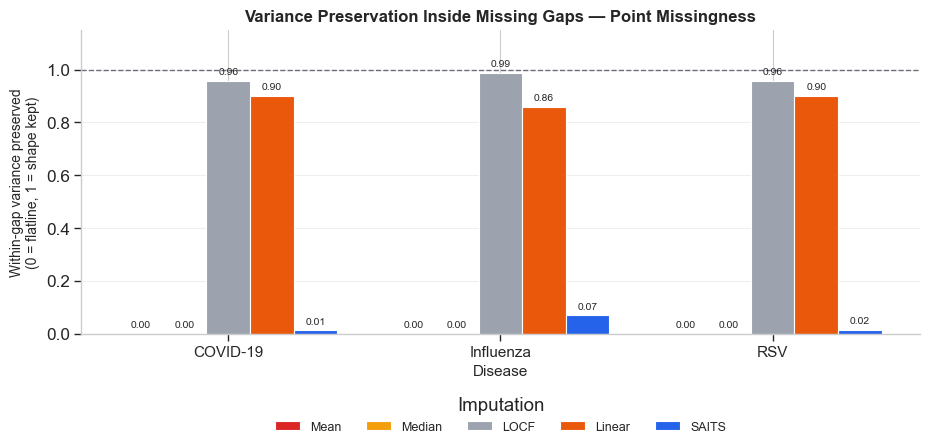

In [16]:
# ============================================================
# FIGURE (updated): Variance Preservation — now including SAITS
# mean/median/LOCF/Linear: re-imputed from raw data.
# SAITS: taken from the actual run output (imputed_series file).
# Computes BOTH Block and Point so you can pick the honest one.
# ============================================================
import pandas as pd, numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
COVID_RAW   = "covid19_multi_mg_final.csv"
FLU_RAW     = "diseases_multi_mg_final.csv"
SERIES_FILE = "imputed_series_for_forecasting.csv"

def make_mask(n, rate, pattern):
    m = np.ones(n, bool)
    k = int(n * rate)
    if k < 1 or k >= n:
        return m
    if pattern == "Block":
        start = np.random.randint(0, n - k)
        m[start:start + k] = False
    else:  # Point: scattered
        idx = np.random.choice(n, k, replace=False)
        m[idx] = False
    return m

def impute(series, mask, method):
    x = series.copy().astype(float)
    x[~mask] = np.nan
    s = pd.Series(x)
    if method == "Mean":   return s.fillna(s.mean()).values
    if method == "Median": return s.fillna(s.median()).values
    if method == "LOCF":   return s.ffill().bfill().values
    if method == "Linear": return s.interpolate().ffill().bfill().values

def var_ratio(true_v, imp_v):
    tv = np.var(true_v)
    return np.var(imp_v) / tv if tv > 0 else np.nan

# ---------- baselines from raw data ----------
def collect_baselines(pattern):
    rec = []
    covid = pd.read_csv(COVID_RAW)
    covid["Date"] = pd.to_datetime(covid["Date"], format="mixed", errors="coerce")
    for ctry, g in covid.groupby("Country/Region"):
        s = g.sort_values("Date")["new_cases"].dropna().values
        if len(s) < 600 or s.std() == 0 or s.sum() < 10000:
            continue
        for rate in [0.1, 0.3, 0.5]:
            mask = make_mask(len(s), rate, pattern)
            tg = s[~mask]
            if len(tg) < 5:
                continue
            for m in ["Mean", "Median", "LOCF", "Linear"]:
                rec.append({"Disease": "COVID-19", "Method": m,
                            "var_ratio": var_ratio(tg, impute(s, mask, m)[~mask])})

    flu = pd.read_csv(FLU_RAW)
    key = ["COUNTRY_AREA_TERRITORY", "ISO_WEEKSTARTDATE"]
    flu = flu.groupby(key, as_index=False)[flu.select_dtypes("number").columns.tolist()].mean()
    flu["ISO_WEEKSTARTDATE"] = pd.to_datetime(flu["ISO_WEEKSTARTDATE"], format="mixed", errors="coerce")
    for target, label in [("INF_ALL", "Influenza"), ("RSV", "RSV")]:
        for ctry, g in flu.groupby("COUNTRY_AREA_TERRITORY"):
            s = g.sort_values("ISO_WEEKSTARTDATE")[target].dropna().values
            if len(s) < 300 or s.std() == 0 or s.sum() < 500:
                continue
            for rate in [0.1, 0.3, 0.5]:
                mask = make_mask(len(s), rate, pattern)
                tg = s[~mask]
                if len(tg) < 5:
                    continue
                for m in ["Mean", "Median", "LOCF", "Linear"]:
                    rec.append({"Disease": label, "Method": m,
                                "var_ratio": var_ratio(tg, impute(s, mask, m)[~mask])})
    return pd.DataFrame(rec)

# ---------- SAITS from the actual run output ----------
def collect_saits(pattern):
    s = pd.read_csv(SERIES_FILE)
    s = s[(s.Method == "SAITS") & (s.Pattern == pattern)]
    dis_map = {"new_cases": "COVID-19", "INF_ALL": "Influenza", "RSV": "RSV"}
    rec = []
    keys = ["Dataset", "Country", "Target", "Rate"]
    for kv, g in s.groupby(keys):
        miss = g[g.WasMissing == True]
        if len(miss) < 5:
            continue
        rec.append({"Disease": dis_map.get(kv[2], kv[2]), "Method": "SAITS",
                    "var_ratio": var_ratio(miss.TrueValue.values,
                                           miss.ImputedValue.values)})
    return pd.DataFrame(rec)

def build_summary(pattern):
    df = pd.concat([collect_baselines(pattern), collect_saits(pattern)]).dropna()
    summ = df.groupby(["Disease", "Method"])["var_ratio"].median().unstack()
    return summ.reindex(columns=["Mean", "Median", "LOCF", "Linear", "SAITS"]) \
               .reindex(["COVID-19", "Influenza", "RSV"])

for pattern in ["Block", "Point"]:
    summary = build_summary(pattern)
    print(f"\n--- {pattern} masking: median within-gap variance ratio ---")
    print(summary.round(3).to_string())

    fig, ax = plt.subplots(figsize=(9.5, 4.8))
    methods = ["Mean", "Median", "LOCF", "Linear", "SAITS"]
    colors  = {"Mean": "#dc2626", "Median": "#f59e0b", "LOCF": "#9ca3af",
               "Linear": "#ea580c", "SAITS": "#2563eb"}
    x = np.arange(len(summary.index))
    w = 0.16
    for i, m in enumerate(methods):
        vals = summary[m].values
        bars = ax.bar(x + (i - 2) * w, vals, w, label=m,
                      color=colors[m], edgecolor="white", linewidth=0.8)
        for b, v in zip(bars, vals):
            if not np.isnan(v):
                ax.text(b.get_x() + b.get_width() / 2, v + 0.015,
                        f"{v:.2f}", ha="center", va="bottom", fontsize=7.5)
    ax.axhline(1.0, color="#111827", lw=1, ls="--", alpha=0.6)
    ax.set_xticks(x)
    ax.set_xticklabels(summary.index, fontsize=11)
    ax.set_ylabel("Within-gap variance preserved\n(0 = flatline, 1 = shape kept)", fontsize=10)
    ax.set_xlabel("Disease", fontsize=11)
    ax.set_title(f"Variance Preservation Inside Missing Gaps — {pattern} Missingness",
                 fontsize=12, fontweight="bold")
    ax.legend(title="Imputation", frameon=False, fontsize=9, ncol=5,
              loc="upper center", bbox_to_anchor=(0.5, -0.17))
    ax.set_ylim(0, 1.15)
    ax.grid(axis="y", alpha=0.3)
    ax.set_axisbelow(True)
    for sp in ["top", "right"]:
        ax.spines[sp].set_visible(False)
    plt.tight_layout()
    plt.savefig(f"Fig_VariancePreservation_{pattern}.png", dpi=300, bbox_inches="tight")
    plt.show()

Median within-gap variance ratio (pooled across diseases):
Method    Mean  Median   LOCF  Linear  SAITS
Pattern                                     
Point      0.0     0.0  0.989   0.886  0.023
Sequence   0.0     0.0  0.930   0.806  0.038
Block      0.0     0.0  0.000   0.019  0.019


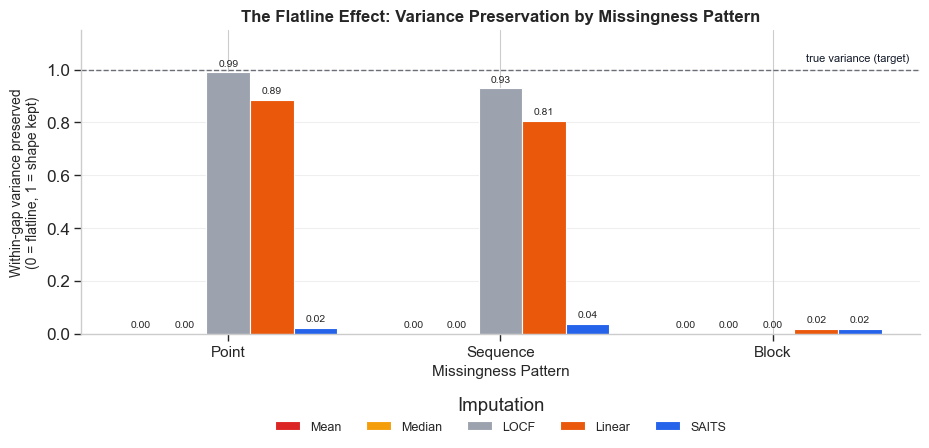

In [36]:
# ============================================================
# FIGURE: Variance Preservation by Missingness Pattern
# x-axis = Point / Sequence / Block ; bars = 5 methods.
# Pooled across all diseases (variance ratio is scale-free, so
# pooling is fair here). Patterns kept separate ON PURPOSE -
# averaging them would hide where the flatline effect bites.
# ============================================================
import pandas as pd, numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
COVID_RAW   = "covid19_multi_mg_final.csv"
FLU_RAW     = "diseases_multi_mg_final.csv"
SERIES_FILE = "imputed_series_for_forecasting.csv"

def make_mask(n, rate, pattern):
    m = np.ones(n, bool)
    k = int(n * rate)
    if k < 1 or k >= n:
        return m
    if pattern == "Block":
        start = np.random.randint(0, n - k)
        m[start:start + k] = False
    elif pattern == "Sequence":
        # several short runs (~4 steps each) until k cells are removed
        removed = 0
        while removed < k:
            run = min(4, k - removed)
            start = np.random.randint(0, n - run)
            m[start:start + run] = False
            removed = (~m).sum()
    else:  # Point
        idx = np.random.choice(n, k, replace=False)
        m[idx] = False
    return m

def impute(series, mask, method):
    x = series.copy().astype(float)
    x[~mask] = np.nan
    s = pd.Series(x)
    if method == "Mean":   return s.fillna(s.mean()).values
    if method == "Median": return s.fillna(s.median()).values
    if method == "LOCF":   return s.ffill().bfill().values
    if method == "Linear": return s.interpolate().ffill().bfill().values

def var_ratio(true_v, imp_v):
    tv = np.var(true_v)
    return np.var(imp_v) / tv if tv > 0 else np.nan

PATTERNS = ["Point", "Sequence", "Block"]

# ---------- baselines from raw data ----------
rec = []
covid = pd.read_csv(COVID_RAW)
covid["Date"] = pd.to_datetime(covid["Date"], format="mixed", errors="coerce")
for ctry, g in covid.groupby("Country/Region"):
    s = g.sort_values("Date")["new_cases"].dropna().values
    if len(s) < 600 or s.std() == 0 or s.sum() < 10000:
        continue
    for pattern in PATTERNS:
        for rate in [0.1, 0.3, 0.5]:
            mask = make_mask(len(s), rate, pattern)
            tg = s[~mask]
            if len(tg) < 5:
                continue
            for m in ["Mean", "Median", "LOCF", "Linear"]:
                rec.append({"Pattern": pattern, "Method": m,
                            "var_ratio": var_ratio(tg, impute(s, mask, m)[~mask])})

flu = pd.read_csv(FLU_RAW)
key = ["COUNTRY_AREA_TERRITORY", "ISO_WEEKSTARTDATE"]
flu = flu.groupby(key, as_index=False)[flu.select_dtypes("number").columns.tolist()].mean()
flu["ISO_WEEKSTARTDATE"] = pd.to_datetime(flu["ISO_WEEKSTARTDATE"], format="mixed", errors="coerce")
for target in ["INF_ALL", "RSV"]:
    for ctry, g in flu.groupby("COUNTRY_AREA_TERRITORY"):
        s = g.sort_values("ISO_WEEKSTARTDATE")[target].dropna().values
        if len(s) < 300 or s.std() == 0 or s.sum() < 500:
            continue
        for pattern in PATTERNS:
            for rate in [0.1, 0.3, 0.5]:
                mask = make_mask(len(s), rate, pattern)
                tg = s[~mask]
                if len(tg) < 5:
                    continue
                for m in ["Mean", "Median", "LOCF", "Linear"]:
                    rec.append({"Pattern": pattern, "Method": m,
                                "var_ratio": var_ratio(tg, impute(s, mask, m)[~mask])})

# ---------- SAITS from the actual run output ----------
s_df = pd.read_csv(SERIES_FILE)
s_df = s_df[s_df.Method == "SAITS"]
for kv, g in s_df.groupby(["Dataset", "Country", "Target", "Pattern", "Rate"]):
    miss = g[g.WasMissing == True]
    if len(miss) < 5:
        continue
    rec.append({"Pattern": kv[3], "Method": "SAITS",
                "var_ratio": var_ratio(miss.TrueValue.values,
                                       miss.ImputedValue.values)})

df = pd.DataFrame(rec).dropna()
summary = df.groupby(["Pattern", "Method"])["var_ratio"].median().unstack()
summary = summary.reindex(index=PATTERNS,
                          columns=["Mean", "Median", "LOCF", "Linear", "SAITS"])
print("Median within-gap variance ratio (pooled across diseases):")
print(summary.round(3).to_string())

# ---------- plot ----------
fig, ax = plt.subplots(figsize=(9.5, 4.8))
methods = ["Mean", "Median", "LOCF", "Linear", "SAITS"]
colors  = {"Mean": "#dc2626", "Median": "#f59e0b", "LOCF": "#9ca3af",
           "Linear": "#ea580c", "SAITS": "#2563eb"}
x = np.arange(len(PATTERNS))
w = 0.16
for i, m in enumerate(methods):
    vals = summary[m].values
    bars = ax.bar(x + (i - 2) * w, vals, w, label=m,
                  color=colors[m], edgecolor="white", linewidth=0.8)
    for b, v in zip(bars, vals):
        if not np.isnan(v):
            ax.text(b.get_x() + b.get_width() / 2, v + 0.015,
                    f"{v:.2f}", ha="center", va="bottom", fontsize=7.5)
ax.axhline(1.0, color="#111827", lw=1, ls="--", alpha=0.6)
ax.text(len(PATTERNS) - 0.5, 1.03, "true variance (target)",
        fontsize=8, ha="right", color="#111827")
ax.set_xticks(x)
ax.set_xticklabels(PATTERNS, fontsize=11)
ax.set_ylabel("Within-gap variance preserved\n(0 = flatline, 1 = shape kept)", fontsize=10)
ax.set_xlabel("Missingness Pattern", fontsize=11)
ax.set_title("The Flatline Effect: Variance Preservation by Missingness Pattern",
             fontsize=12, fontweight="bold")
ax.legend(title="Imputation", frameon=False, fontsize=9, ncol=5,
          loc="upper center", bbox_to_anchor=(0.5, -0.17))
ax.set_ylim(0, 1.15)
ax.grid(axis="y", alpha=0.3)
ax.set_axisbelow(True)
for sp in ["top", "right"]:
    ax.spines[sp].set_visible(False)
plt.tight_layout()
plt.savefig("Fig_VariancePreservation_byPattern.png", dpi=300, bbox_inches="tight")
plt.show()